# Reading data from massive ECCC file

In [3]:
import pandas as pd
import os
from math import ceil

def split_excel_file(
    file_path: str,
    output_dir: str,
    rows_per_file: int = 100000,
    sheet_name: str = 0
) -> list:
    """
    Splits a large Excel file into multiple smaller files.
    
    Parameters:
    -----------
    file_path : str
        Path to the input Excel file
    output_dir : str
        Directory where split files will be saved
    rows_per_file : int
        Number of rows per output file
    sheet_name : str or int
        Sheet to read from the Excel file
        
    Returns:
    --------
    list
        List of paths to the created files
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Get total number of rows
    print("Counting rows...")
    nrows = pd.read_excel(file_path, sheet_name=sheet_name).shape[0]
    
    # Calculate number of files needed
    num_files = ceil(nrows / rows_per_file)
    output_files = []
    
    print(f"Splitting {nrows} rows into {num_files} files...")
    
    for i in range(num_files):
        # Calculate row range for this chunk
        start_row = i * rows_per_file
        
        # Read chunk of rows
        print(f"Reading rows {start_row} to {start_row + rows_per_file}...")
        df_chunk = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            skiprows=start_row,
            nrows=rows_per_file
        )
        
        # Generate output filename
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        output_file = os.path.join(output_dir, f"{base_name}_part_{i+1}.xlsx")
        
        # Save chunk to new file
        print(f"Saving {output_file}...")
        df_chunk.to_excel(output_file, index=False)
        output_files.append(output_file)
        
        # Clear memory
        del df_chunk
        
    print(f"Successfully split file into {len(output_files)} parts")
    return output_files

## Change in load 
According to the report from ECCC
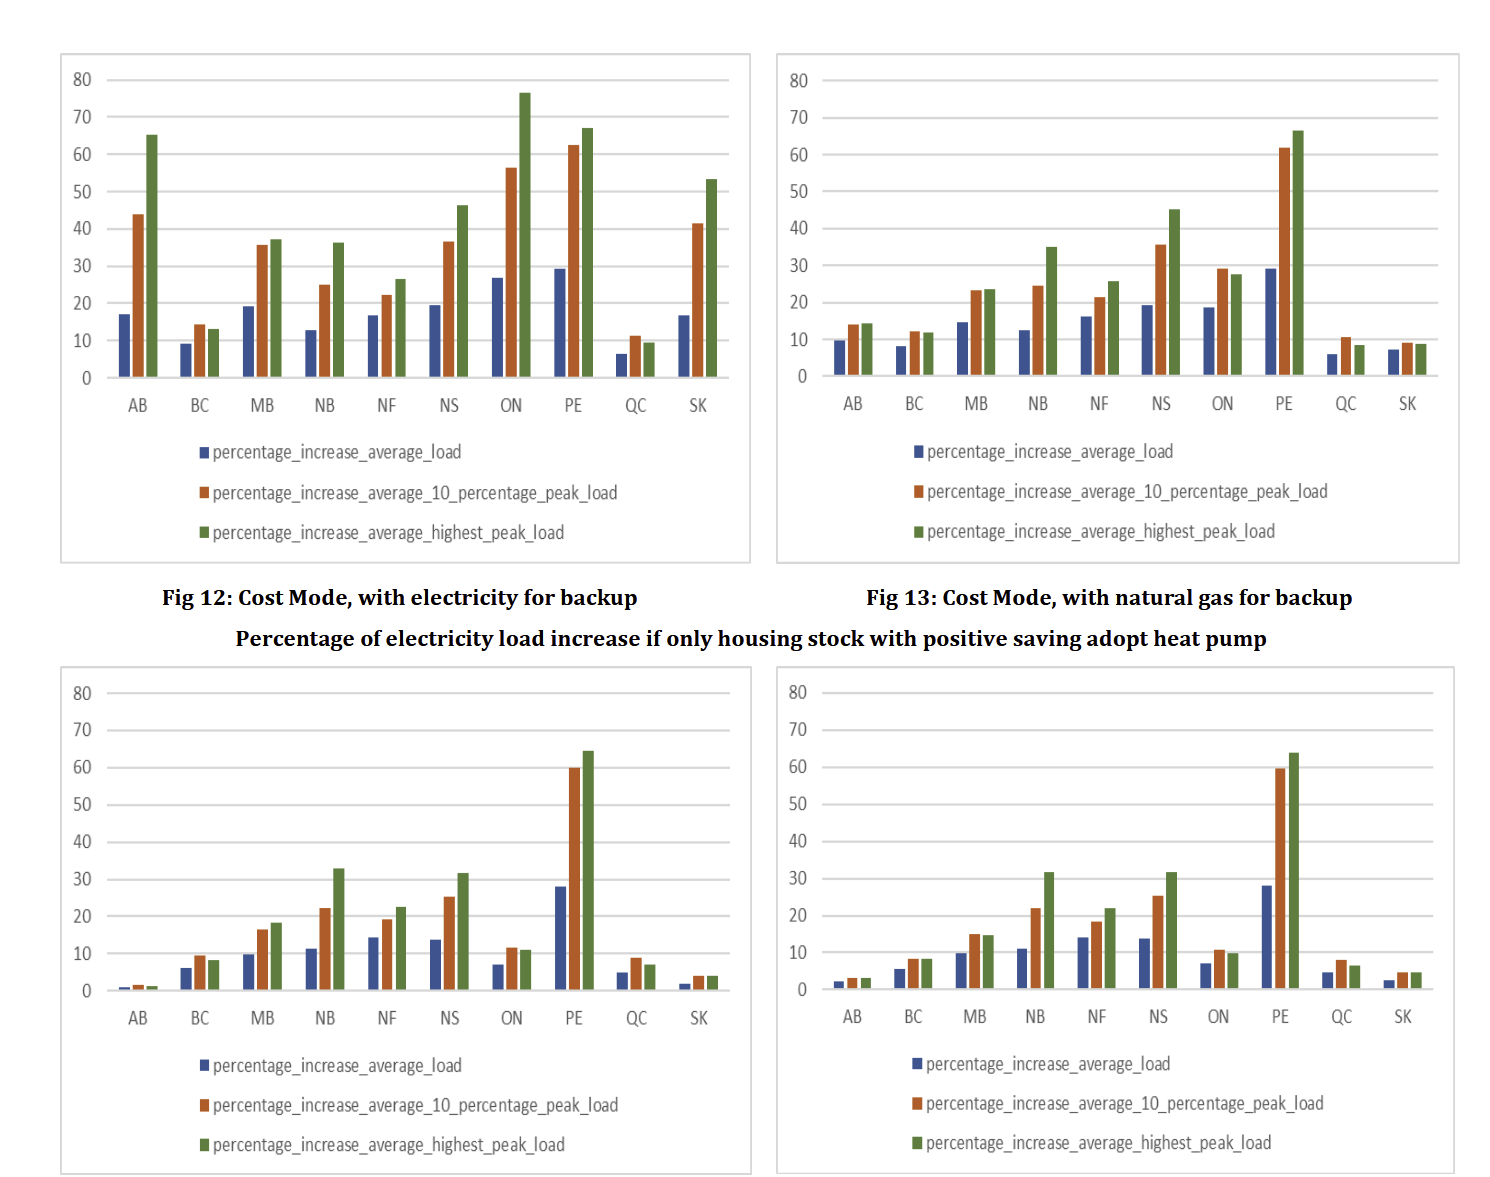

## Reading the data 

In [162]:
import pandas as pd
import glob
base_folder = '../data/raw_data/heatpump/ECCC_data_parts/'
filenames = glob.glob(f'{base_folder}*part*') 
filenames.sort()
print("Reading filename :", filenames[3])
data_part= pd.read_excel(filenames[3])

Reading filename : ../data/raw_data/heatpump/ECCC_data_parts\ECCC_2023_part_13.xlsx


## Data column descriptions

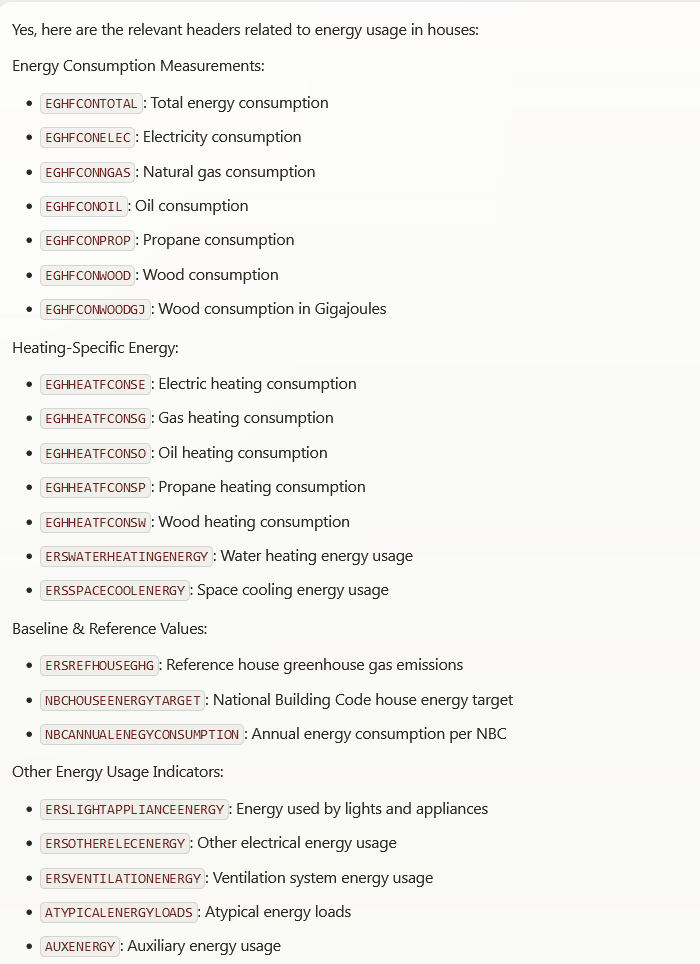

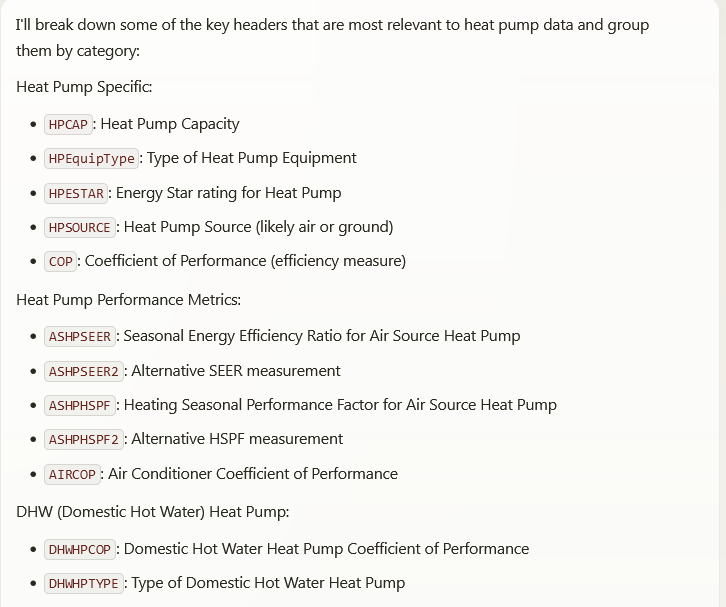

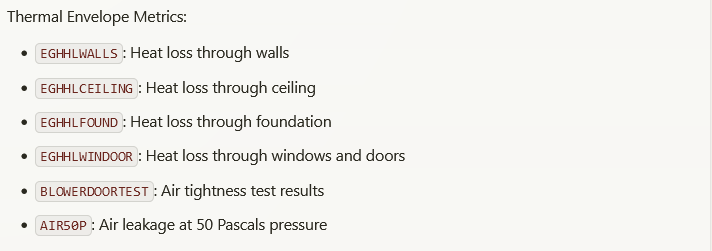

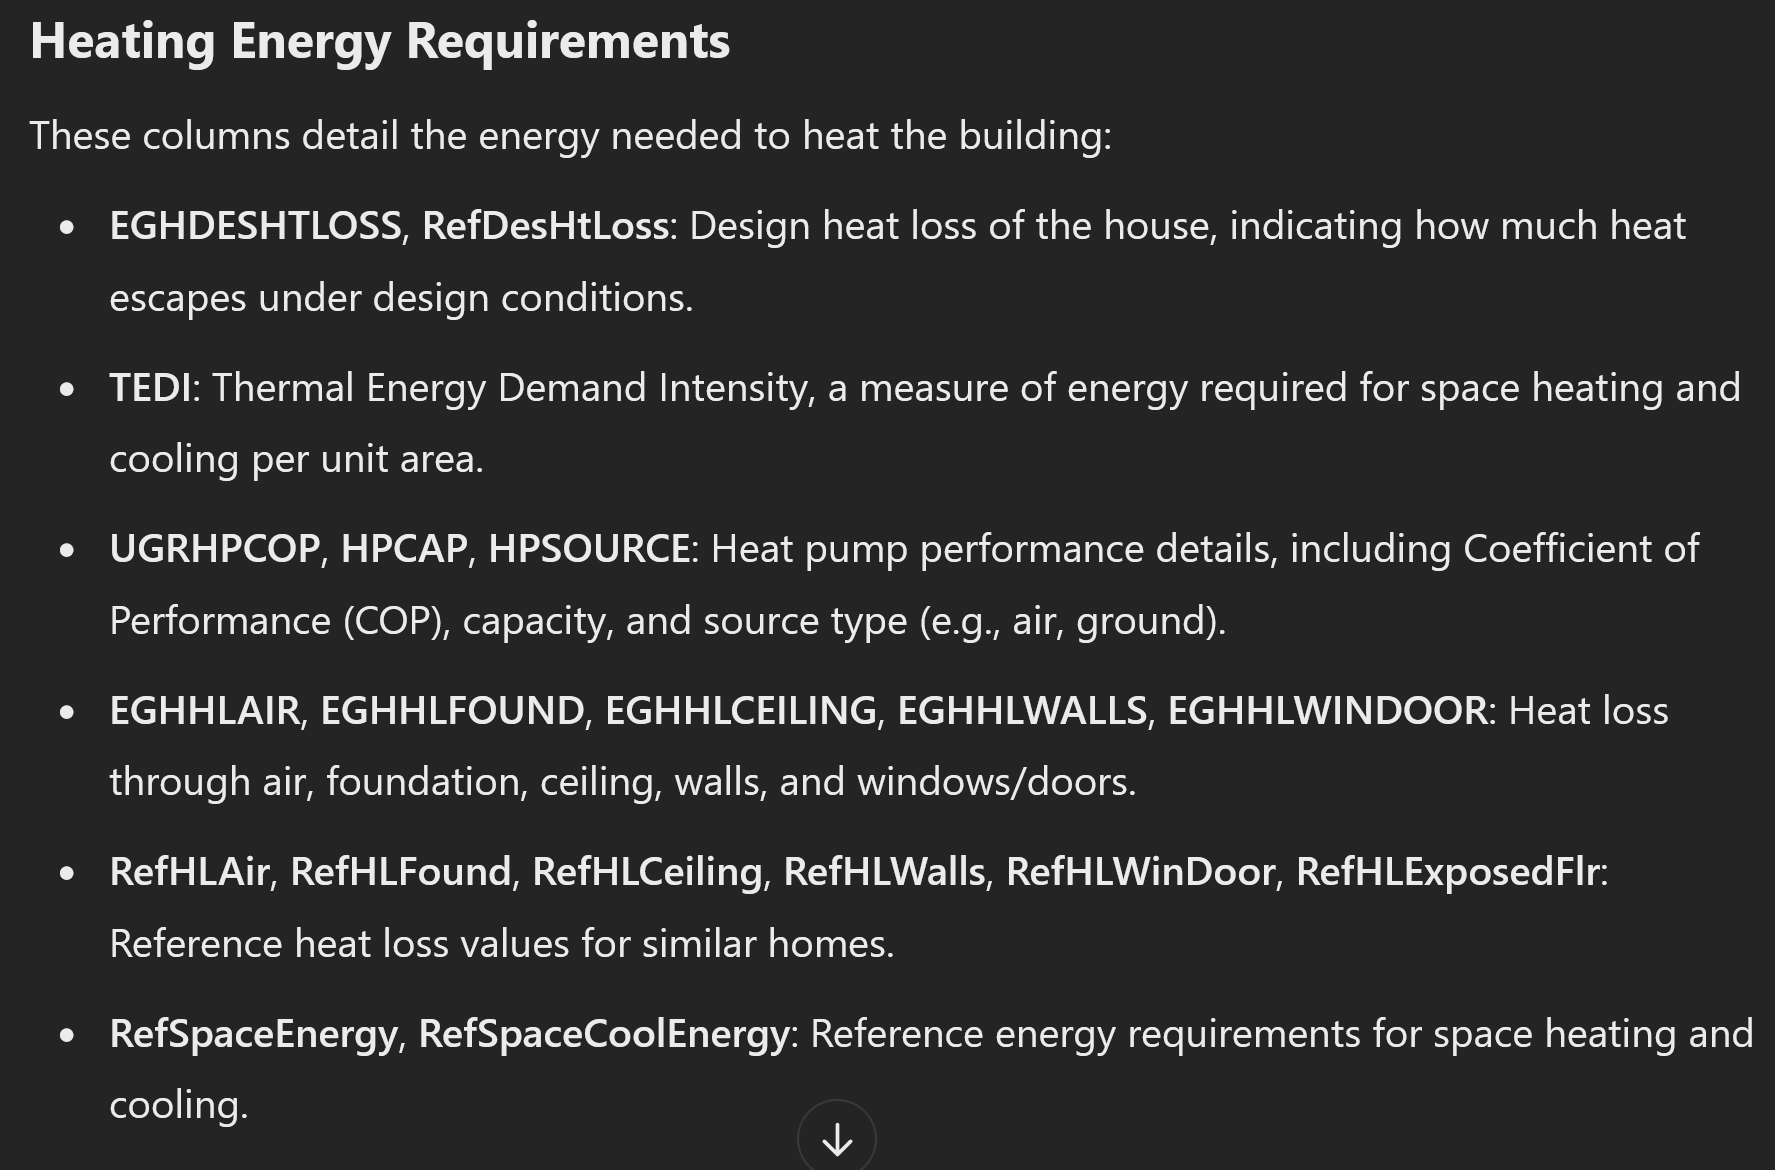

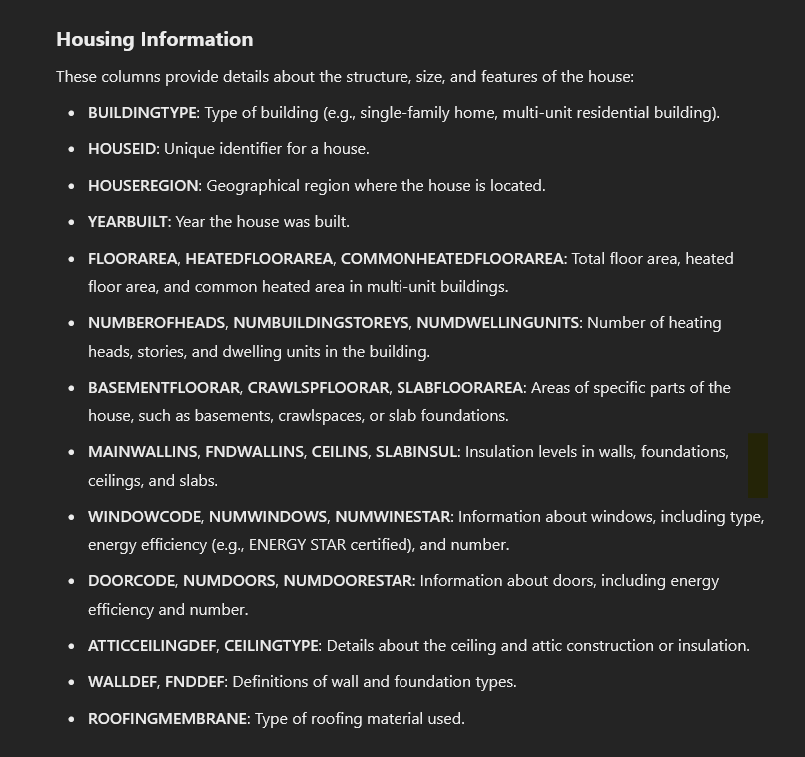

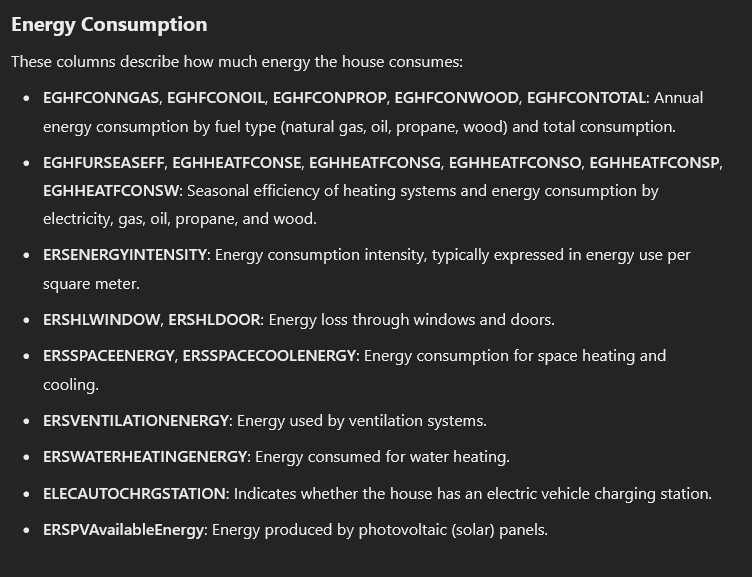

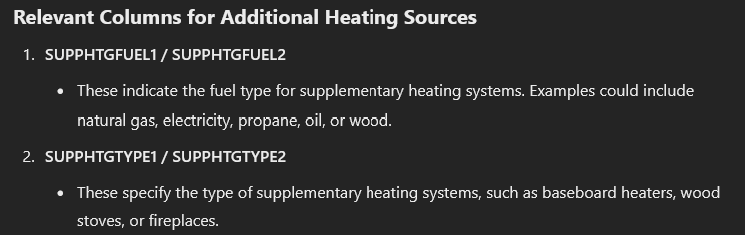

https://data.open-power-system-data.org/when2heat/2023-07-27/README.md

## Understanding the data

In [101]:
heatpumpdata = ['HPCAP', 'HPEquipType', 'HPESTAR' ,'HPSOURCE', 'COP']
building_chars = ['HEATEDFLOORAREA', 'BUILDINGTYPE', 'HOUSEID', 'HOUSEREGION', 'YEARBUILT']
location_data = ['HOUSEREGION', 'CLIENTPCODE', 'CLIENTCITY']

thermal_envelope_metrics = ['EGHHLWALLS', 'EGHHLCEILING', 'EGHHLWINDOOR', 'EGHHLFOUND', 'EGHHLEXPOSEDFLR',  'EGHHLAIR']
energy_performance = ['EGHRATING', 'EGHSPACEENERGY', 'ERSENERGYINTENSITY']
energy_consumption_metrics = ['EGHFCONTOTAL' ,'EGHFCONELEC','EGHFCONNGAS','EGHFCONOIL' , 'EGHFCONPROP','EGHFCONWOOD','EGHFCONWOODGJ']
heating_specific_eng_consumption_metrics = ['EGHHEATFCONSE', 
                                            'EGHHEATFCONSG', 
                                            'EGHHEATFCONSO', 
                                            'EGHHEATFCONSP' ,
                                            'EGHHEATFCONSW',
                                            'ERSWATERHEATINGENERGY',
                                            'EGHSPACEENERGY',
                                            'ERSSPACECOOLENERGY']
weather_data = ['WEATHERLOC', 'WTHDATA', 'CoolingSeasonMonths', 'TMAIN', 'QTOT', 'QWARN']
temperature_setting = ['ThermostatCooling', 'ThermostatHeatingNighttime']
time_info = ['CREATIONDATE', 'ENTRYDATE']

#efficiency of the heating equipment

EGHHLWALLS 23740.511322626906
EGHHLCEILING 8598.873755974773
EGHHLWINDOOR 29199.72953209856
EGHHLFOUND 30065.93131264511
EGHHLEXPOSEDFLR 850.5484399011292
EGHHLAIR 24090.979184412623


Text(0, 0.5, '#houses')

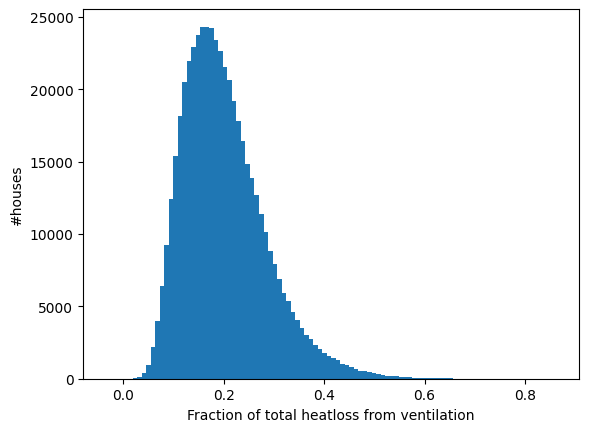

In [105]:
import numpy as np 
import matplotlib.pyplot as plt 
for c in thermal_envelope_metrics:
    print(c, hp_data[c].mean())
thermal_data = np.array(hp_data[thermal_envelope_metrics])
plt.hist(thermal_data[:,-1]/thermal_data.sum(axis=1), bins=100)
plt.xlabel('Fraction of total heatloss from ventilation')
plt.ylabel('#houses')



In [443]:
sum(data_no_dup[' HPESTAR']=='C448')


42

In [341]:
data[230]

array([  326. , 81254. ,     0. ,     0. ,     0. , 26123.6, 81580.1,
        3629.7])

uniq_id

In [141]:
data_part[data_part[' HOUSEID']==1108107.0 ].to_json('./house_1108107.json')

In [61]:
data_no_dup = data_part.drop_duplicates()

In [197]:
data_no_dup.columns

Index(['ACCENTESTAR', ' ACMODELNUMBER', ' ACWINDESTAR', ' ACWINDNUM', ' AHRI',
       ' AIR50P', ' AIRCONDTYPE', ' AIRCOP', ' ASHPHSPF', ' ASHPHSPF2',
       ...
       ' RefHLWinDoor', ' RefHLExposedFlr', ' RefHLWindow', ' RefHLDoor',
       ' RefDesHtLoss', ' RefDesCoolLoss', ' RefSpaceEnergy',
       ' RefSpaceCoolEnergy', ' RefWaterHeatEnergy', ' RefVentilationEnergy'],
      dtype='object', length=435)

In [198]:
data_no_dup[weather_data]

,WEATHERLOC,WTHDATA,CoolingSeasonMonths,TMAIN,QTOT,QWARN
0,"L'ASSOMPTION,QUEBEC",Wth2020,0.0,21,22.63,32.00
1,"NICOLET,QUEBEC",Wth2020,6.0,21,53.09,19.99
2,"NICOLET,QUEBEC",Wth2020,0.0,21,51.68,19.99
3,"BARRAGE TEMISCAMINGUE,QUEBEC",Wth2020,0.0,21,69.13,19.58
4,"OTTAWA INTL,ONTARIO",Wth2020,0.0,21,32.05,32.00
...,...,...,...,...,...,...
9995,"VERNON,BRITISH COLUMBIA",Wth2020,NaN,21,40.84,24.97
9996,"VERNON,BRITISH COLUMBIA",Wth2020,NaN,21,40.84,24.97
9997,"VERNON,BRITISH COLUMBIA",Wth2020,NaN,21,40.84,24.97
9998,"VERNON,BRITISH COLUMBIA",Wth2020,NaN,21,40.84,24.97


# Heat pump home heating cycle

In [21]:
opcycle_data = pd.read_csv('../../data/raw_data/heatpump/when2heat.csv', sep=';')


In [22]:
opcycle_data_2022 = opcycle_data[opcycle_data['utc_timestamp'].str.contains('2022')]

In [503]:
opcycle_data_2022

,utc_timestamp,cet_cest_timestamp,AT_COP_ASHP_floor,AT_COP_ASHP_radiator,AT_COP_ASHP_water,AT_COP_GSHP_floor,AT_COP_GSHP_radiator,AT_COP_GSHP_water,AT_COP_WSHP_floor,AT_COP_WSHP_radiator,...,SK_heat_demand_water,SK_heat_demand_water_COM,SK_heat_demand_water_MFH,SK_heat_demand_water_SFH,SK_heat_profile_space_COM,SK_heat_profile_space_MFH,SK_heat_profile_space_SFH,SK_heat_profile_water_COM,SK_heat_profile_water_MFH,SK_heat_profile_water_SFH
122724,2022-01-01T00:00:00Z,2022-01-01T01:00:00+0100,"3,46","3,01","2,45","4,5","3,67","2,73","5,07","4,12",...,NaN,NaN,NaN,NaN,88,78,74,88,71,15
122725,2022-01-01T01:00:00Z,2022-01-01T02:00:00+0100,"3,45",3,"2,45","4,49","3,66","2,73","5,06","4,11",...,NaN,NaN,NaN,NaN,98,77,77,67,69,12
122726,2022-01-01T02:00:00Z,2022-01-01T03:00:00+0100,"3,47","3,01","2,45","4,51","3,68","2,73","5,07","4,13",...,NaN,NaN,NaN,NaN,103,86,86,84,66,23
122727,2022-01-01T03:00:00Z,2022-01-01T04:00:00+0100,"3,48","3,03","2,44","4,55","3,72","2,74","5,08","4,15",...,NaN,NaN,NaN,NaN,116,110,107,104,106,54
122728,2022-01-01T04:00:00Z,2022-01-01T05:00:00+0100,"3,47","3,02","2,44","4,55","3,72","2,74","5,08","4,14",...,NaN,NaN,NaN,NaN,137,168,147,125,145,169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131478,2022-12-31T19:00:00Z,2022-12-31T20:00:00+0100,"3,55","3,1","2,37","4,56","3,76","2,63","5,1","4,2",...,NaN,NaN,NaN,NaN,187,225,229,83,139,148
131479,2022-12-31T20:00:00Z,2022-12-31T21:00:00+0100,"3,5","3,04","2,35","4,48","3,68","2,6","5,07","4,15",...,NaN,NaN,NaN,NaN,182,204,203,93,134,126
131480,2022-12-31T21:00:00Z,2022-12-31T22:00:00+0100,"3,5","3,03","2,35","4,46","3,66","2,59","5,07","4,14",...,NaN,NaN,NaN,NaN,161,174,148,84,122,74
131481,2022-12-31T22:00:00Z,2022-12-31T23:00:00+0100,"3,46","2,99","2,33","4,41","3,6","2,58","5,04","4,09",...,NaN,NaN,NaN,NaN,150,127,122,62,91,30


In [20]:
import re
import math
opcycle_data_cols = opcycle_data.columns

heating_pattern_24h_all = pd.DataFrame(columns = ['building_type', 'hour', 'fraction_of_daily_heating'])


rel_strs = [ r'.*_heat_profile_space_SFH', r'.*_heat_profile_space_COM', r'.*_heat_profile_space_MFH']
relevant_cols =  [col for col in opcycle_data_cols if re.match(rel_str, col) ]

# for cols in relevant_cols:
#     print(opcycle_data[cols].sum())
for rel_str in rel_strs:
    heating_pattern_24h = pd.DataFrame(columns = ['building_type', 'hour', 'fraction_of_daily_heating'])
    relevant_cols =  [col for col in opcycle_data_cols if re.match(rel_str, col) ]

    heating_profiles = np.array(opcycle_data_2022[relevant_cols])
    print(heating_profiles.shape)
    num_countries = 28
    daily_heating_profile = np.zeros((num_countries, 24))
    for i in range(num_countries):
        country_data= heating_profiles[:, i]
        indx_rel = math.floor(country_data.shape[0]/24)*24
        
        hourly_country_data = country_data[0:indx_rel].reshape(math.floor(country_data.shape[0]/24), 24).mean(axis=0)
        daily_heating_profile[i,:] = hourly_country_data
    
    
    daily_heating_profile_mean = daily_heating_profile.mean(axis=0)
    daily_heating_profile_mean_norm = daily_heating_profile_mean/daily_heating_profile_mean.sum()
    heating_pattern_24h['building_type']= [rel_str.split('_')[-1]]*24
    heating_pattern_24h['hour'] = np.arange(24)
    heating_pattern_24h['fraction_of_daily_heating'] = daily_heating_profile_mean_norm
    heating_pattern_24h_all = pd.concat([heating_pattern_24h_all, heating_pattern_24h])

# plt.plot(daily_heating_profile_mean_norm)
# daily_heating_profile_mean_norm.sum()
# plt.plot(daily_heating_profile.T)
# print(opcycle_data['SE_heat_profile_space_MFH'].mean())
# print(opcycle_data['DE_heat_profile_space_MFH'].mean())
heating_pattern_24h_all.to_csv('../../data/formatted_data/heatpump/normalized_24h_heating_pattern.csv')

NameError: name 'opcycle_data' is not defined

In [603]:
heating_pattern_24h_all

,building_type,hour,fraction_of_daily_heating
0,SFH,0,0.024717
1,SFH,1,0.027156
2,SFH,2,0.032787
3,SFH,3,0.042619
4,SFH,4,0.051832
...,...,...,...
19,MFH,19,0.046079
20,MFH,20,0.039736
21,MFH,21,0.031521
22,MFH,22,0.025458


'MFH'

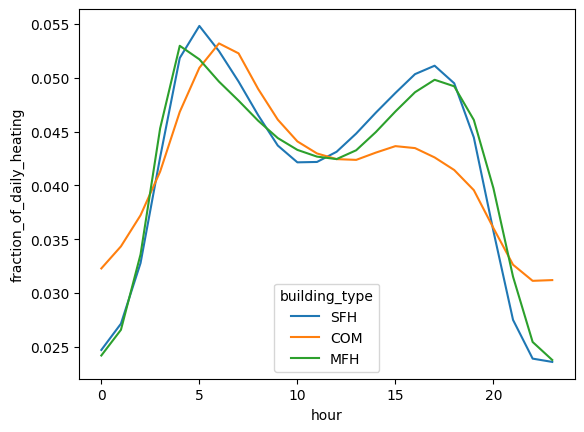

In [549]:
sns.lineplot(heating_pattern_24h_all, x='hour', y='fraction_of_daily_heating', hue='building_type')
rel_str.split('_')[-1]

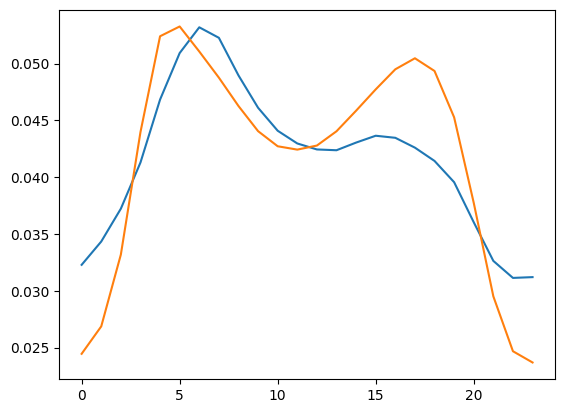

In [531]:
plt.plot(daily_heating_profile_mean_norm_com)
plt.plot(daily_heating_profile_mean_norm_res)

# Getting weather data

In [278]:
import requests
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry

def get_lat_lon(city_or_postal, api_key='c65af5e86ba0434b958b89eca2995f83'):
    """
    Get latitude and longitude for a given city name or postal code using OpenCage API.
    """
    geocode_url = "https://api.opencagedata.com/geocode/v1/json"
    params = {
        "q": city_or_postal,
        "key": api_key,
    }
    response = requests.get(geocode_url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data['results']:
            location = data['results'][0]['geometry']
            return location['lat'], location['lng']
        else:
            raise ValueError("Location not found!")
    else:
        response.raise_for_status()

def get_historical_weather(lat, lon, start_date, end_date):
    """
    Fetch historical hourly weather data from Open-Meteo API.
    """
    weather_url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m",
        "timezone": "auto",
    }
    response = requests.get(weather_url, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        response.raise_for_status()


def get_historical_weather_data_formatted(lat, long, start_date, end_date, openmeteo):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
    	"latitude": lat,
    	"longitude": long,
    	"hourly": ["temperature_2m", 'wind_speed_10m'],
    	"timezone": "auto",
    	"start_date": start_date,
    	"end_date": end_date
    }
    responses = openmeteo.weather_api(url, params=params)
    
    # Process first location. Add a for-loop for multiple locations or weather models
    response = responses[0]
    print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation {response.Elevation()} m asl")
    print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
    print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")
    
    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
    hourly_wind_speed_10m = hourly.Variables(1).ValuesAsNumpy()
    
    hourly_data = {"date": pd.date_range(
    	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
    	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
    	freq = pd.Timedelta(seconds = hourly.Interval()),
    	inclusive = "left"
    )}
    hourly_data["temperature_2m"] = hourly_temperature_2m
    hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
    
    hourly_dataframe = pd.DataFrame(data = hourly_data)
    return hourly_dataframe
    

In [259]:
# find the number of unique locations in the heatpump data
import glob 
import pandas as pd 
import tqdm
base_folder = '../data/raw_data/heatpump/ECCC_data_parts/'
filenames = glob.glob(f'{base_folder}/*')
# cities_with_FSA = []
# total_pcodes = []
for f in tqdm.tqdm(filenames[3:]):
    data = pd.read_excel(f)
    locations = set(data[' CLIENTCITY'].str.strip().str.lower()+ ','+ data[' HOUSEREGION'].str.strip().str.lower() + ',' +data[' CLIENTPCODE'].str.strip().str.lower())
    pcodes = set(data[' CLIENTPCODE'].str.strip().str.lower())
    print("Num of cities: ", len(locations))
    print("Num of pcodes: ", len(pcodes))
    cities_with_FSA.extend(locations)
    total_pcodes.extend(pcodes)
    cities_with_FSA = list(set(cities_with_FSA))
    total_pcodes = list(set(total_pcodes))
    print("New total cities: ", len(cities_with_FSA))
    print("New total pcodes: ", len(total_pcodes))



  2%|▉                                         | 1/47 [00:22<17:25, 22.73s/it]

Num of cities:  2135
Num of pcodes:  1021
New total cities:  4211
New total pcodes:  1163


  4%|█▊                                        | 2/47 [00:45<17:16, 23.04s/it]

Num of cities:  2138
Num of pcodes:  1022
New total cities:  4746
New total pcodes:  1180


  6%|██▋                                       | 3/47 [01:10<17:23, 23.71s/it]

...

Num of cities:  1494
Num of pcodes:  574
New total cities:  14778
New total pcodes:  1734


 98%|████████████████████████████████████████▏| 46/47 [19:52<00:24, 24.77s/it]

Num of cities:  1448
Num of pcodes:  585
New total cities:  14859
New total pcodes:  1735


100%|█████████████████████████████████████████| 47/47 [20:16<00:00, 25.88s/it]

Num of cities:  1248
Num of pcodes:  679
New total cities:  14956
New total pcodes:  1736


In [279]:
import time
#get weather data for the respective cities
save_folder = '../data/raw_data/weather/by_FSA'
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)
# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below

start_date = '2023-01-01'
end_date = '2024-01-01'

# weather_info_dict = {}
# city_latlong = {}

#fsa_latlong =  {}
#fsa_weather_info_dict = {}
for fsa in total_pcodes:
    print(fsa)
    if fsa not in fsa_latlong.keys():
        print("Performing coord search")
        try:
            lat, long = get_lat_lon(fsa)
            fsa_latlong[fsa] = [lat, long]
        except:
            #city_latlong[fd] = [None, None]
            print(f"Location data not found for {fsa}. Skipping. . . ")
    
    try:    
        lat, long = fsa_latlong[fsa]
        
        weather_data = get_historical_weather_data_formatted(lat, long, start_date, end_date, openmeteo)
        weather_data['FSA'] = fsa
        fsa_weather_info_dict[fsa] = weather_data
        weather_data.to_csv(f'{save_folder}/{fsa}_{start_date}_{end_date}.csv')
    except Exception as e:
        print("problem getting weather information")
        print(e)
        
    time.sleep(3)

#last location: saint-simon, québec


Performing coord search
Location data not found for . Skipping. . . 
problem getting weather information
''
e7n
Coordinates 46.080841064453125°N -67.5357666015625°E
Elevation 160.0 m asl
Timezone b'America/Moncton' b'GMT-4'
Timezone difference to GMT+0 -14400 s
s6x
Coordinates 53.1810188293457°N -105.68182373046875°E
Elevation 454.0 m asl
Timezone b'America/Regina' b'GMT-6'
Timezone difference to GMT+0 -21600 s
g0t
Coordinates 49.033390045166016°N -69.608154296875°E
Elevation 527.0 m asl
Timezone b'America/Toronto' b'GMT-5'
Timezone difference to GMT+0 -18000 s
h7c
Coordinates 45.588748931884766°N -73.58493041992188°E
Elevation 29.0 m asl
Timezone b'America/Toronto' b'GMT-5'
Timezone difference to GMT+0 -18000 s
e4c
Coordinates 45.86994552612305°N -65.93353271484375°E
Elevation 0.0 m asl
Timezone b'America/Moncton' b'GMT-4'
Timezone difference to GMT+0 -14400 s
t2a
Coordinates 51.07205581665039°N -114.03227233886719°E
Elevation 1064.0 m asl
Timezone b'America/Edmonton' b'GMT-7'
Timezo

# Calculate hourly heating requirement from annual heating and hourly weather data

In [70]:
heatpumpdata = ['HPCAP', 'HPEquipType', 'HPESTAR' ,'HPSOURCE', 'COP']
building_chars = ['HEATEDFLOORAREA', 'BUILDINGTYPE', 'HOUSEID', 'HOUSEREGION', 'YEARBUILT']
location_data = ['HOUSEREGION', 'CLIENTPCODE', 'CLIENTCITY']

thermal_envelope_metrics = ['EGHHLWALLS', 'EGHHLCEILING', 'EGHHLWINDOOR', 'EGHHLFOUND', 'EGHHLEXPOSEDFLR',  'EGHHLAIR']
energy_performance = ['EGHRATING', 'EGHSPACEENERGY', 'ERSENERGYINTENSITY']
energy_consumption_metrics = ['EGHFCONTOTAL' ,'EGHFCONELEC','EGHFCONNGAS','EGHFCONOIL' , 'EGHFCONPROP','EGHFCONWOOD','EGHFCONWOODGJ']
heating_specific_eng_consumption_metrics = ['EGHHEATFCONSE', 
                                            'EGHHEATFCONSG', 
                                            'EGHHEATFCONSO', 
                                            'EGHHEATFCONSP' ,
                                            'EGHHEATFCONSW',
                                            'ERSWATERHEATINGENERGY',
                                            'EGHSPACEENERGY',
                                            'ERSSPACECOOLENERGY']
weather_data = ['WEATHERLOC', 'WTHDATA', 'CoolingSeasonMonths', 'TMAIN', 'QTOT', 'QWARN']
temperature_setting = ['ThermostatCooling', 'ThermostatHeatingNighttime']
time_info = ['CREATIONDATE', 'ENTRYDATE']

#efficiency of the heating equipment

In [273]:
import pandas as pd 
# read a row from the ECCC
# fname = '../data/raw_data/heatpump/ECCC_data_parts/ECCC_2023_part_10.xlsx'
# housing_data = pd.read_excel(fname)


def calculate_hourly_annual_heating_cooling_requirement_for_house(housing_data_row, 
                                                          base_indoor_temp=20, 
                                                          cooling_trigger_temp=24,
                                                          weather_filepath='../../data/raw_data/weather/by_FSA/{0}_2023-01-01_2024-01-01.csv',
                                                          heating_pattern='../../data/formatted_data/heatpump/normalized_24h_heating_pattern.csv'):
    '''h
    Given housing information, retrieve yearly temperature and calculate the hourly heating energy
    required by the house
    housing_data: One row from ECCC_2023 db


    Returns 
        hourly_heating_energy_total: numpy array containing annual hourly heating requirement in KJ
        hourly_cooling_energy_total: numpy array containing annual hourly cooling requirement in KJ
        hourly_heating_degrees: array
        hourly_cooling_degrees: array
        hourly_temp_data : array in celcius

    '''
    
    thermal_envelope_metrics = ['EGHHLWALLS', 'EGHHLCEILING', 'EGHHLWINDOOR', 'EGHHLFOUND', 'EGHHLEXPOSEDFLR',  'EGHHLAIR']    
    # read relevant data
    building_fsa = housing_data_row['CLIENTPCODE']
    annual_heating_eng_req = housing_data_row['EGHSPACEENERGY']*1000 #MJ to KJ
    annual_cooling_eng_req = housing_data_row['ERSSPACECOOLENERGY']*1000  #MJ to KJ  
    heatloss_data = np.array(housing_data_row[thermal_envelope_metrics])
    
    weather_data = pd.read_csv(weather_filepath.format(building_fsa))
    if heating_pattern:
        heating_pattern_data = pd.read_csv(heating_pattern)
    
    # calculate the hourly temperature and wind factor 
    temp_contribution = heatloss_data[0:-2].sum()
    wind_contribution = heatloss_data[-1]
    
    temp_fraction = temp_contribution/heatloss_data.sum()
    wind_fraction = 1-temp_fraction
    
    hourly_temp_data = np.array(weather_data['temperature_2m'])
    hourly_wind_data = np.array(weather_data['wind_speed_10m'])
    hourly_heating_degrees = base_indoor_temp - hourly_temp_data
    
    hourly_heating_degrees[ hourly_heating_degrees <= 0] = 0
    hourly_wind_data[hourly_heating_degrees <= 0] = 0
    
    temp_factor = (annual_heating_eng_req*temp_fraction)/hourly_heating_degrees.sum()
    wind_factor = (annual_heating_eng_req*wind_fraction)/np.sum(hourly_wind_data)
    
    # calclulate the hourly heating energy 
    hourly_heating_energy_temp = temp_factor*hourly_heating_degrees 
    hourly_heating_energy_wind = wind_factor*hourly_wind_data
    
    hourly_heating_energy_total = hourly_heating_energy_temp + hourly_heating_energy_wind
    # add heating pattern into the mix 
    if heating_pattern:
        hourly_heating_energy_total = hourly_heating_energy_total.reshape(-1, 24)
        hourly_heating_energy_total_daily = hourly_heating_energy_total.sum(axis=1).reshape(hourly_heating_energy_total.shape[0], 1)
        daily_norm = np.array(heating_pattern_data[heating_pattern_data['building_type']=='SFH']['fraction_of_daily_heating']).reshape(1, 24)
        daily_norm_stacked = np.repeat(daily_norm, hourly_heating_energy_total.shape[0], axis=0)
        hourly_heating_energy_total = np.multiply(daily_norm_stacked, hourly_heating_energy_total_daily).reshape(-1,1)

    
    # calculate the hourly cooling energy
    hourly_cooling_degrees = hourly_temp_data - cooling_trigger_temp
    hourly_cooling_degrees[hourly_cooling_degrees <= 0] = 0
    temp_factor_cooling = (annual_cooling_eng_req)/hourly_cooling_degrees.sum()
    hourly_cooling_energy_total = temp_factor_cooling*hourly_cooling_degrees 
    

    return hourly_heating_energy_total, hourly_cooling_energy_total, hourly_heating_degrees, hourly_cooling_degrees, hourly_temp_data
    

45380999.99999993 5138400.000000001


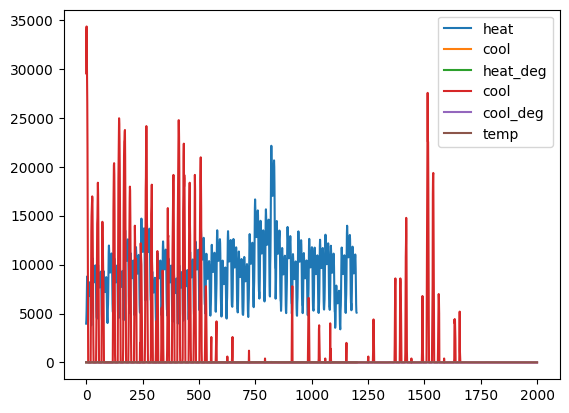

In [641]:
eccc_df_hp_row = eccc_df[eccc_df['HPSOURCE'].isin(['Air', 'Water', 'Land'])].iloc[23]
heat, cool, heat_deg, cool_deg,  temp = calculate_hourly_annual_heating_cooling_requirement_for_house(eccc_df_hp_row, cooling_trigger_temp=23)
print(heat.sum(), cool.sum())
plt.plot(heat[0:1200], label='heat')
plt.plot(cool[0:1200], label='cool')

plt.plot(heat_deg[0:1200], label='heat_deg')

plt.plot(cool[4500:6500], label='cool')
plt.plot(cool_deg[4500:6500], label='cool_deg')

plt.plot(temp[4500:6500], label='temp')
plt.legend()

In [637]:
cool.sum(), heat.sum()

(45380999.99999999, 45380999.99999993)

(2067679.5744578845, 2067679.5744578873)

## Plot hourly heat requirement vs temperature and wind

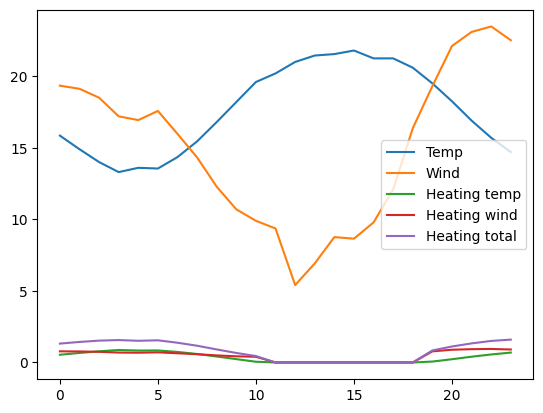

In [552]:

import matplotlib.pyplot as plt
start = 24*181
end = 24*182
plt.plot(np.array(weather_data['temperature_2m'])[start:end],label='Temp')
plt.plot(np.array(weather_data['wind_speed_10m'])[start: end], label='Wind')
plt.plot(hourly_heating_energy_temp[start: end], label='Heating temp')
plt.plot(hourly_heating_energy_wind[start: end], label='Heating wind')
plt.plot(hourly_heating_energy_total[start: end], label='Heating total')
plt.legend()

# Convert heat requirement to electricity consumption

## Interpolate heatpump data

In [4]:
import pandas as pd 
hp_data_file = '../../data/raw_data/heatpump/ECCC_2023.csv'
hp_data = pd.read_csv(hp_data_file)

C:\Users\konar\AppData\Local\Temp\ipykernel_54164\1014841373.py:3: DtypeWarning: Columns (47,52,87,88,89,151,157,158,183,213,223,227,230,233,256,257,259,275,279,284,326,330,331,347,351,353,358) have mixed types. Specify dtype option on import or set low_memory=False.
  hp_data = pd.read_csv(hp_data_file)


Text(0, 0.5, '#houses')

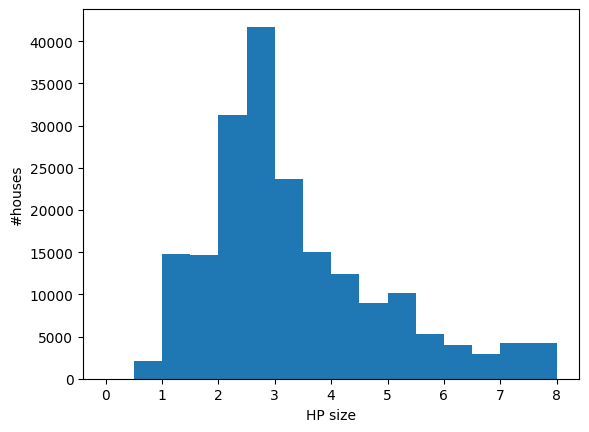

In [99]:
import numpy as np
import matplotlib.pyplot as plt
non_zero_hp_cap = hp_data[hp_data['HPCAP'] > 3500*0.5]
bins= [0,0.5,1,1.5,2,2.5,3,3.5,4,4.5, 5, 5.5, 6, 6.5, 7, 8]
plt.hist(non_zero_hp_cap['HPCAP']/3500, bins=bins)
plt.xlabel('HP size')
plt.ylabel('#houses')

In [52]:
heat_pump_specs_data = pd.read_excel('../../data/raw_data/heatpump/heatpump_specifications.xlsx')
print(list(heat_pump_specs_data[heat_pump_specs_data['hp_cap_ton']==1].index))
heat_pump_specs_data.loc[list(heat_pump_specs_data[heat_pump_specs_data['hp_cap_ton']==1].index)]['temperature_c']
heat_pump_specs_data

[0, 1, 2, 3, 4, 5]


,hp_cap_ton,temperature_c,cap_low,cap_high,cop_low,cop_high
0,1.0,-30.00,0.075,0.35,0.56,1.04
1,1.0,-15.00,0.180,0.95,2.08,1.99
2,1.0,-8.30,0.300,1.07,2.58,2.14
3,1.0,8.30,0.440,1.35,5.55,3.59
4,1.0,27.70,0.340,1.27,8.58,6.59
...,...,...,...,...,...,...
58,5.0,-15.00,0.150,0.89,1.89,2.10
59,5.0,-8.30,0.170,0.87,2.00,2.41
60,5.0,8.30,0.190,1.10,4.10,3.76
61,5.0,27.78,0.300,1.07,5.43,4.52


In [296]:
# 2d interpolation 
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator, NearestNDInterpolator, RegularGridInterpolator
from scipy.interpolate import CubicSpline
import pandas as pd
import json
hp_data_file = '../../data/raw_data/heatpump/heatpump_specifications.xlsx'
hp_data = pd.read_excel(hp_data_file)
hp_caps = list(hp_data['hp_cap_ton'].unique())

#spline fitting in 1d 
interpolated_hp_data = pd.DataFrame(columns=['hp_cap_watts', 'temperature_c', 'cap_low','cap_high', 'cop_low', 'cop_high'])
cols_to_interpol = ['cap_low','cap_high', 'cop_low', 'cop_high']
for hp_capacity in hp_caps:
    interp_df = pd.DataFrame(columns=['hp_cap_watts', 'temperature_c', 'cap_low','cap_high', 'cop_low', 'cop_high'])
    for col in cols_to_interpol:
        relevant_indx = list(heat_pump_specs_data[heat_pump_specs_data['hp_cap_ton']==hp_capacity].index)
        
        csl = CubicSpline(np.array(hp_data.loc[relevant_indx]['temperature_c']), np.array(hp_data.loc[relevant_indx][col]))
        start_temp = -25
        end_temp = 35
        xnew = np.linspace(start_temp, end_temp, num=(end_temp-start_temp)*10+1)
        interp_data = csl(xnew)
        interp_df[col] = interp_data
    interp_df['temperature_c'] = xnew
    interp_df['hp_cap_watts'] = hp_capacity*3500
    interpolated_hp_data = pd.concat([interpolated_hp_data, interp_df])

#interpolated_hp_data.to_excel('../data/raw_data/heatpump/heatpump_specifications_interpolated.xlsx')

#interpolation of the data 

hp_coeff_data_interpolated = {}
len_for_each_hp_data = xnew.shape[0]
for i in range(len(hp_caps)):
    
    x = np.array(interpolated_hp_data['temperature_c'][len_for_each_hp_data*i:len_for_each_hp_data*(i+1)])
    x = np.concatenate([x,x])
    y = np.concatenate([np.array(interpolated_hp_data['cap_low'][len_for_each_hp_data*i:len_for_each_hp_data*(i+1)]), 
                        np.array(interpolated_hp_data['cap_high'][len_for_each_hp_data*i:len_for_each_hp_data*(i+1)])])
    z = np.concatenate([np.array(interpolated_hp_data['cop_low'][len_for_each_hp_data*i:len_for_each_hp_data*(i+1)]), 
                        np.array(interpolated_hp_data['cop_high'][len_for_each_hp_data*i:len_for_each_hp_data*(i+1)])])
    interp = LinearNDInterpolator(list(zip(x,y)),z)
    start_temp = -25
    end_temp = 35
    Xnew = np.linspace(start_temp, end_temp, num=(end_temp-start_temp)*10+1)
    Ynew = np.linspace(0, max(y), num=100)
    X,Y = np.meshgrid(Xnew,Ynew)
    Z = interp(X,Y)
    #add COP for cycling
    cycling_cop_penalty = (1 - 0.15) # from the ECCC heatpump report
    min_vals_for_temps = np.min(Z, where= ~np.isnan(Z), axis=0, initial=10)
    cycling_cop = min_vals_for_temps*cycling_cop_penalty
    for t in range(Z.shape[1]):
        cap_idx = int((y[t] - Ynew.min())/(Ynew.max()-Ynew.min())*len(Ynew))

        Z[0:cap_idx, t] = cycling_cop[t]
     
    hp_coeff_data_interpolated[hp_caps[i]] = {}
    hp_coeff_data_interpolated[hp_caps[i]]['COP_data'] = Z.tolist()
    hp_coeff_data_interpolated[hp_caps[i]]['temp_limits'] = [start_temp, end_temp]
    hp_coeff_data_interpolated[hp_caps[i]]['CAP_max'] = list(y[int(len(y)/2):])
    
with open('../../data/formatted_data/heatpump/hp_coeff_data_interpolated.json', 'w') as fwrite:
    json.dump(hp_coeff_data_interpolated, fwrite)

C:\Users\konar\AppData\Local\Temp\ipykernel_54164\436621492.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  interpolated_hp_data = pd.concat([interpolated_hp_data, interp_df])


In [112]:

interpolated_hp_data.keys()

dict_keys(['COP_data', 'temp_limits', 'CAP_max'])

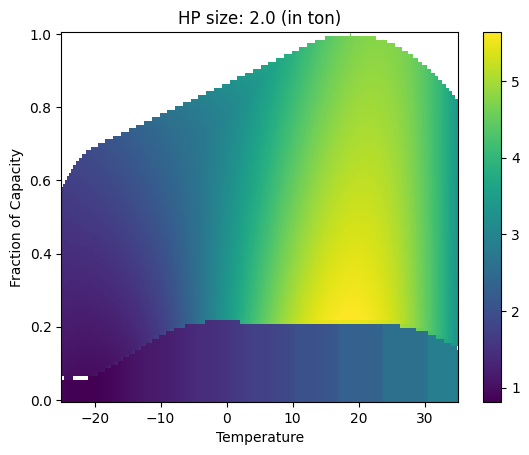

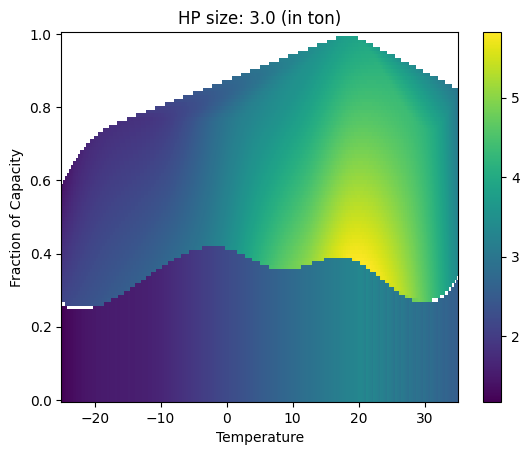

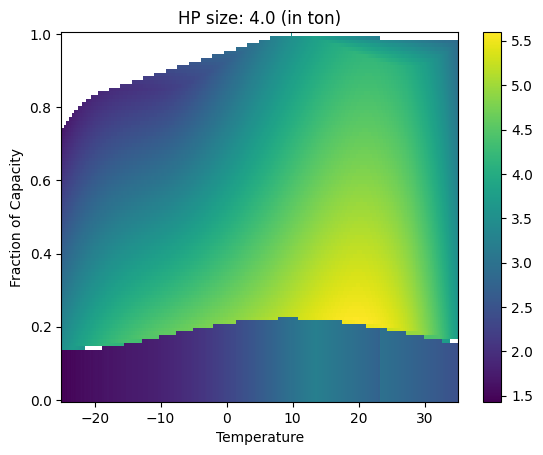

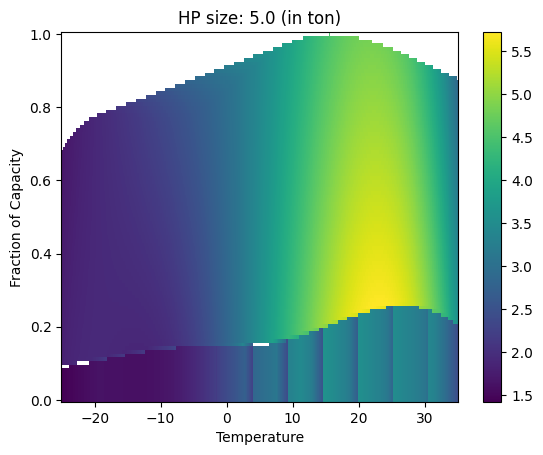

In [117]:
for val in [2.0, 3.0, 4.0, 5.0]:
    Z = hp_coeff_data_interpolated[str(val)]['COP_data']
    interpolated_hp_data = hp_coeff_data_interpolated[str(val)]
    start_temp = -25
    end_temp = 35
    Xnew = np.linspace(start_temp, end_temp, num=(end_temp-start_temp)*10+1)
    Ynew = np.linspace(0, 1, num=100)
    X,Y = np.meshgrid(Xnew,Ynew)
    plt.pcolormesh(X, Y, Z, shading='auto')
    plt.colorbar()
    plt.title(f'HP size: {val} (in ton)')
    plt.xlabel('Temperature')
    plt.ylabel('Fraction of Capacity')
    plt.show()

## Convert Heating requirement to electrical load

In [106]:
import json
import numpy as np
import matplotlib.pyplot as plt
with open('../../data/formatted_data/heatpump/hp_coeff_data_interpolated.json', 'r') as fread:
    hp_coeff_data_interpolated = json.load(fread)



In [269]:
#get load for an hour
import math

def find_closest_non_nan(arr, index):
    """
    Find the closest non-NaN value to the given index in a numpy array.
    
    Args:
        arr (numpy.ndarray): Input array
        index (int): Index to search around
    
    Returns:
        float: Closest non-NaN value, or NaN if no non-NaN values exist
    """
    if not np.isnan(arr[index]):
        return arr[index]
    
    # Search in both directions
    for offset in range(1, len(arr)):
        print('here')
        left = index - offset
        right = index + offset
        
        # Check left side
        if left >= 0 and not np.isnan(arr[left]):
            return arr[left]
        
        # Check right side
        if right < len(arr) and not np.isnan(arr[right]):
            return arr[right]
    
    return np.nan
    
def get_hp_electricity_usage_per_hour(hp_size, cur_temp, cur_heat_req, hp_cop_data):
    '''
    Given the current heating load and size of the heat pump, 
    return the COP and the electricity used by the HP for the current load\
    hp_size: size of the heatpump 
    cur_temp: current temperature
    cur_heat_req: current heating or cooling energy required (KJ)
    hp_cop_info: dictionary containing another dict:
        {hp_size}: {
        'temp_limits': tuple (min, max)
        'CAP_max': list of max capacity values for different temperatures 
        'COP_data': list(list) COP data for different temperature and capacity
                    outer_dim: capacity index
                    inner_dim: temperature index
                    }
    Returns the 
        electric power required (KWh), 
        COP (float)  
        additional heating required from secondary heating (KJ)
    '''
    cur_hp_info = hp_cop_data[str(hp_size)]
    min_temp, max_temp = cur_hp_info['temp_limits']
    min_cap = 0
    max_cap = max(cur_hp_info['CAP_max'])
    max_cap_vals = cur_hp_info['CAP_max']
    cur_temp = max(cur_temp, min_temp) 
    cur_temp = min(cur_temp, max_temp)
    
    temp_indx = int((cur_temp - min_temp)/(max_temp-min_temp)*(len(cur_hp_info['COP_data'][0])-1))
    max_cap_temp = cur_hp_info['CAP_max'][temp_indx]

    # HPsize (in ton) * 3500 = wattage of the HP
    # wattage of HP * 3600 = Joues of heat generated in an hour at 100% capacity
    #Joues of heat generated in an hour at 100% capacity/1000 = KJ of heat genearted at max capacity in an hour
    
    hp_heat_gen_at_100_percent_cap_kj = hp_size*3500*3600/1000 # in KJ 

    cur_load_frac = cur_heat_req/hp_heat_gen_at_100_percent_cap_kj

    cur_load_frac = min(max_cap_temp, cur_load_frac)

    #due to the quirks of the interpolation some edge values are Nan
    #the loop below makes sure if a value is selected from the nan region
    #then it would select the closest non nan value for that given temperature
    cap_indx = math.floor((cur_load_frac - min_cap)/(max_cap - min_cap)*(len(cur_hp_info['COP_data'])-1))
    cur_cop = cur_hp_info['COP_data'][cap_indx][temp_indx]
    
    if np.isnan(cur_cop):
        cur_cop = find_closest_non_nan(np.array(cur_hp_info['COP_data'])[:, temp_indx], cap_indx-1)
    
    #cur_cop = 0.5
    # print(hp_size, cur_hp_info['CAP_max'][temp_indx])
    # print(cur_hp_info['CAP_max'][temp_indx]*hp_size*3500*3600/1000, cur_heat_req)
    
    heat_gen = cur_load_frac*hp_heat_gen_at_100_percent_cap_kj #in KJ
    elec_use = heat_gen/cur_cop/3600 #in KWh (3600KJ = 1KWh)
    return elec_use, cur_cop,  cur_heat_req - heat_gen


In [347]:
import datetime 
ts = datetime.datetime.now()
for i in range(10000):
    get_hp_electricity_usage_per_hour(4.0, 8.3, 4*3500*3.6*1.07 , hp_coeff_data_interpolated)
print(datetime.datetime.now()-ts)

0:00:00.154939


In [270]:
#get electricity consumption for one house over a year


def get_hourly_electricity_usage_for_house(house_data, hp_cop_data):
    '''
    Given the data of a house and the heatpump COP data, return the annual hourly electricity used by that house
    for heating and cooling
    house_data : One row from the ECCC_2023 dataset. Relevant columns include: HPCAP, CLIENTPCODE (for weather), EGHSPACEENERGY, ERSSPACECOOLENERGY
    hp_cop_data: dictionary containing another dict:
        {hp_size}: {
        'temp_limits': tuple (min, max)
        'CAP_max': list of max capacity values for different temperatures 
        'COP_data': list(list) COP data for different temperature and capacity
                    outer_dim: capacity index
                    inner_dim: temperature index
                    }

    returns a dataframe with hp_heating_electricity (KWh), hp_cooling_electricity)(KWh), backup_cooling_electricity (KJ), backup_heating_electricity(KJ)
    '''

    #get hourly heating/cooling energy required
    heat_req, cool_req, _, _, hourly_temp_data = calculate_hourly_annual_heating_cooling_requirement_for_house(house_data)

    #get heatpump size 
    hp_caps_standard = np.arange(1, 5.5, 0.5)
    house_hp_cap = house_data['HPCAP'].item()/3500 #HPCAP is provided in watts
    house_hp_size = hp_caps_standard[np.abs(hp_caps_standard - house_hp_cap).argmin()]
    
    total_hours = len(heat_req)
    hourly_heating_electric_load = np.zeros(total_hours)
    hourly_cooling_electric_load = np.zeros(total_hours)
    heating_cop = np.zeros(total_hours)
    cooling_cop = np.zeros(total_hours)
    addl_heat_hourly = np.zeros(total_hours)
    addl_cool_hourly = np.zeros(total_hours)
    for t in range(total_hours):
        cur_temp = hourly_temp_data[t]
        if heat_req[t] > 0:
            elec_use, cur_cop,  addl_heat_req = get_hp_electricity_usage_per_hour(house_hp_size, cur_temp, heat_req[t], hp_cop_data)
            heating_cop[t] = cur_cop
            addl_heat_hourly[t] = addl_heat_req
            hourly_heating_electric_load[t] = elec_use
            
        if cool_req[t] > 0:
            elec_use, cur_cop,  addl_cool_req = get_hp_electricity_usage_per_hour(house_hp_size, cur_temp, cool_req[t], hp_cop_data)
            cooling_cop[t] = cur_cop
            addl_cool_hourly[t] = addl_cool_req
            hourly_cooling_electric_load[t] = elec_use

    house_hr_load = pd.DataFrame()
    house_hr_load['heating_load_KWh'] = hourly_heating_electric_load
    house_hr_load['cooling_load_KWh'] = hourly_cooling_electric_load
    house_hr_load['heating_COP_KJ'] = heating_cop
    house_hr_load['cooling_COP_KJ'] = cooling_cop 
    house_hr_load['hourly_temp'] = hourly_temp_data
    house_hr_load['province'] = house_data['HOUSEREGION']
    house_hr_load['fsa'] = house_data['CLIENTPCODE']
    
    return house_hr_load
    #return hourly_heating_electric_load, hourly_cooling_electric_load, heating_cop, cooling_cop , addl_heat_hourly, addl_cool_hourly


In [294]:
import seaborn as sns
hp_data[hp_data['HOUSEID']==2027706.0]
# eccc_df_hp_row = eccc_df[eccc_df['HPSOURCE'].isin(['Air', 'Water', 'Land'])].iloc[109229]
# hr_data = get_hourly_electricity_usage_for_house(eccc_df_hp_row, hp_coeff_data_interpolated)
# #hr_data
# sns.lineplot(hr_data[['heating_load_KWh', 'cooling_load_KWh']].iloc[24*30:24*35])
# ax2 = plt.twinx()
# #sns.lineplot(hr_data['hourly_temp'].iloc[24*30:24*35], color="red", ax=ax2)

,ACCENTESTAR,ACMODELNUMBER,ACWINDESTAR,ACWINDNUM,AHRI,AIR50P,AIRCONDTYPE,AIRCOP,ASHPHSPF,ASHPHSPF2,...,RefHLWinDoor,RefHLExposedFlr,RefHLWindow,RefHLDoor,RefDesHtLoss,RefDesCoolLoss,RefSpaceEnergy,RefSpaceCoolEnergy,RefWaterHeatEnergy,RefVentilationEnergy


In [271]:
eccc_df_hp_row = eccc_df[eccc_df['HPSOURCE'].isin(['Air', 'Water', 'Land'])].iloc[109029]
heat_load, cool_load, heating_cop, cooling_cop, addl_heat, addl_cool = get_hourly_electricity_usage_for_house(eccc_df_hp_row, hp_coeff_data_interpolated)
print('heat : ', (heat_load*heating_cop).sum()/1000*3600)
print('heat addl: ', addl_heat.sum()/1000)
print('cool addl: ', addl_cool.sum()/1000)
print('Cool : ', (cool_load*cooling_cop).sum()/1000*3600)
print(eccc_df_hp_row['EGHSPACEENERGY'], eccc_df_hp_row['ERSSPACECOOLENERGY'])

NameError: name 'eccc_df' is not defined

In [359]:
heat_load

array([3.09961664, 3.21524716, 3.21293631, ..., 3.09202514, 3.08626674,
       3.11011501])

In [140]:
get_hp_electricity_usage_per_hour(4.5, 34.9, 4.5*3500*0.18, hp_coeff_data_interpolated)

(728.72644256362, 3.89034874324942, -13858.445486286608)

# Penetration rate of heat pumps



In [4]:
import pandas as pd
from matplotlib import pyplot as plt 
import numpy as np
hp_penetration_rate_province = pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_province.csv')


C:\Users\konar\AppData\Local\Temp\ipykernel_57012\3395537578.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast_penrate_provinces = pd.concat([forecast_penrate_provinces, forecast_penrate_one_province])


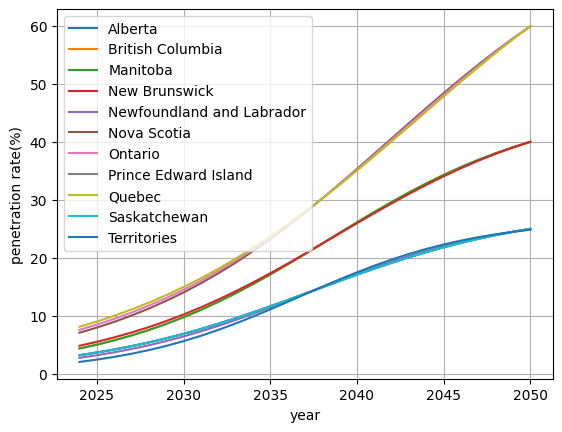

In [5]:
from scipy.optimize import curve_fit
def logistic(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))
    

forecast_penrate_provinces = pd.DataFrame(columns=['province', 'year', 'penetration_rate'])
#penetration_forecast = {2024: 6, 2030: 13, 2040: 30, 2050: 50}
penetration_forecast = {'high': {2024: 7, 2030: 15, 2040: 35, 2050: 60}, 
                        'med': {2024: 4, 2030: 10, 2040: 26, 2050: 40}, 
                        'low': {2024: 2, 2030: 7, 2040: 17, 2050: 25}
                       }
provinces = list(hp_penetration_rate_province['province'])
for province in provinces:
    years = []
    pen_rates = []
    forecast_penrate_one_province = pd.DataFrame(columns=['province', 'year', 'penetration_rate'])
    cur_penrate_province = hp_penetration_rate_province[hp_penetration_rate_province['province']==province]['penetration_rate'].item()

    if cur_penrate_province >= 6.4:
        key= 'high'
    elif cur_penrate_province < 6.4 and  cur_penrate_province > 4:
        key = 'med'
    else:
        key = 'low' 
    for year, p_rate in penetration_forecast[key].items():
        years.append(year)
        pen_rates.append(p_rate)
    
    cur_penrate_province = hp_penetration_rate_province[hp_penetration_rate_province['province']==province]['penetration_rate'].item()
    #proportional_rate = cur_penrate_province/penetration_forecast[key][2024]
    pen_rates_proportional = np.array(pen_rates) #*proportional_rate*0.9
    pen_rates_proportional[0] = cur_penrate_province
    initial_guess = [pen_rates_proportional[-1], 0.1, 2030] 
    popt, _ = curve_fit(logistic, years, pen_rates_proportional, p0=initial_guess)
    pred_years = np.arange(2024, 2051)
    pen_rates_forecast = logistic(pred_years, *popt)
    plt.plot(pred_years, pen_rates_forecast, label=province)
    forecast_penrate_one_province['province'] = [province]*len(pen_rates_forecast)
    forecast_penrate_one_province['year'] = pred_years
    forecast_penrate_one_province['penetration_rate'] = pen_rates_forecast
    forecast_penrate_provinces = pd.concat([forecast_penrate_provinces, forecast_penrate_one_province])

plt.legend()
plt.xlabel('year')
plt.ylabel('penetration rate(%)')
plt.grid(True)


In [ ]:
forecast_penrate_provinces.to_csv('../../data/formatted_data/heatpump/hp_penetration_rate_province_yearly.csv')

<Axes: xlabel='year', ylabel='penetration_rate'>

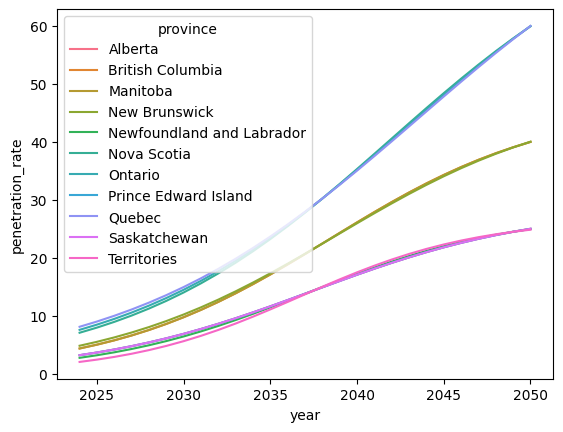

In [19]:
dd=  pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_province_yearly.csv')
sns.lineplot(dd, x='year', y='penetration_rate', hue='province')

# Expanding to nationwide

## Current penetration rate across different Groups

Each group is a combination of these 4 factors:
- Province
- Year of construction
- Building type
- Heating Type

In [9]:
import glob
import numpy as np
fnames = glob.glob('../../data/formatted_data/heatpump/housing_distribution_heatpumps/*')

In [10]:
import pandas as pd
master_df = pd.DataFrame()
for fname in fnames:
    province_name = fname.split('\\')[1].split('_')[0]
    province_data = pd.read_csv(fname)
    province_data['province_name'] = province_name
    master_df = pd.concat([master_df, province_data])
master_df['Total'].sum()

15903856

In [11]:
house_types = master_df['HouseType'].unique()
heating_type_cols = ['Heat Pump', 'Electric', 'Propane', 'Wood', 'Oil' , 'Natural Gas']

master_df.rename(columns={'Unnamed: 1': 'year_of_construction'}, inplace=True)

heating_data = np.array(master_df[heating_type_cols])
hp_penetration_rate = heating_data[:, 0]/heating_data.sum(axis=1)
master_df['hp_penetration_rate'] = hp_penetration_rate
master_df['fraction_of_housing'] = ['']* len(master_df)

province_list = master_df['province_name'].unique()

for province in province_list:
    heating_data_province = np.array(master_df[master_df['province_name']==province][heating_type_cols])
    master_df.loc[master_df['province_name']==province, 'fraction_of_housing'] = heating_data_province.sum(axis=1)/heating_data_province.sum().astype(float)

hp_penetration_rate_shaped = hp_penetration_rate.reshape(-1, 11)

#province_wise_mean_pen_rate = master_df.groupby('province_name', as_index=False).mean('hp_penetration_rate')


master_df['hp_penetration_rate_proportional'] = ['']* len(master_df)

for province in province_list:
    pen_rate_by_group = np.array(master_df[master_df['province_name']==province]['hp_penetration_rate'])
    province_wise_mean_pen_rate = (pen_rate_by_group*np.array(master_df[master_df['province_name']==province]['fraction_of_housing'])).sum()

    
    pen_rate_by_group_proportional = (np.array(pen_rate_by_group) - province_wise_mean_pen_rate)/province_wise_mean_pen_rate/2 + 1
    #pen_rate_by_group_proportional = np.array(pen_rate_by_group)/province_wise_mean_pen_rate
    #print(pen_rate_by_group_proportional)
    if not np.any(np.isnan(pen_rate_by_group_proportional)):
        master_df.loc[master_df['province_name']==province, 'hp_penetration_rate_proportional'] = pen_rate_by_group_proportional
    else:
        master_df.loc[master_df['province_name']==province, 'hp_penetration_rate_proportional'] = [1]* len(pen_rate_by_group_proportional)


C:\Users\konar\AppData\Local\Temp\ipykernel_57012\3059025451.py:29: RuntimeWarning: invalid value encountered in divide
  pen_rate_by_group_proportional = (np.array(pen_rate_by_group) - province_wise_mean_pen_rate)/province_wise_mean_pen_rate/2 + 1


In [12]:
master_df.to_csv('../../data/formatted_data/heatpump/hp_penetration_rate_by_group_all_province.csv')

In [14]:
hp_penetration_rate_province_yearly = pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_province_yearly.csv')
hp_pen_rate_current = pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_by_group_all_province.csv')
heating_type_cols = ['Heat Pump', 'Electric', 'Propane', 'Wood', 'Oil' , 'Natural Gas']

province_list = hp_penetration_rate_province_yearly['province'].unique()
province_list_abb = hp_pen_rate_current['province_name'].unique()
years = hp_penetration_rate_province_yearly['year'].unique()
group_wise_yearly_penetration_rate_forecast_full = pd.DataFrame(columns=['province', 'house_type', 'year_of_construction', 'number_of_houses', 'forecast_year', 'hp_penetration_rate'])

print(province_list, province_list_abb)
for p_full, p_abb in zip(province_list, province_list_abb):
    pen_forecast_province = np.array(hp_penetration_rate_province_yearly[hp_penetration_rate_province_yearly['province']==p_full]['penetration_rate'])
    cur_province_pen = hp_pen_rate_current[hp_pen_rate_current['province_name']==p_abb]
    for _, row in cur_province_pen.iterrows():
        forecast_df = pd.DataFrame(columns=['province', 'house_type', 'year_of_construction', 'number_of_houses', 
                                            'electric', 'non_electric', 'forecast_year', 'hp_penetration_rate'])
        forecast_df['province'] = [p_full] * len(years)
        forecast_df['house_type'] = [row['HouseType']] * len(years)
        forecast_df['number_of_houses'] = [row[heating_type_cols].sum()] * len(years)
        forecast_df['electric'] = [row['Electric']] * len(years)
        forecast_df['non_electric'] = [row[['Propane', 'Wood', 'Oil' , 'Natural Gas']].sum()] * len(years)
        forecast_df['year_of_construction'] = [row['year_of_construction']] * len(years)
        forecast_df['forecast_year'] = years
        forecast_df['hp_penetration_rate'] = np.minimum(100, np.array(hp_penetration_rate_province_yearly[
                                                hp_penetration_rate_province_yearly['province']==p_full
                                                                ]['penetration_rate'])*row['hp_penetration_rate_proportional'])
        
        group_wise_yearly_penetration_rate_forecast_full = pd.concat([group_wise_yearly_penetration_rate_forecast_full, forecast_df])



group_wise_yearly_penetration_rate_forecast_full.loc[group_wise_yearly_penetration_rate_forecast_full['house_type']=='Appartment', 'house_type'] = 'Apartment'

group_wise_yearly_penetration_rate_forecast_full.rename(columns={'forecast_year': 'Year', 'hp_penetration_rate': 'Penetration Rate (%)'}, inplace=True)


['Alberta' 'British Columbia' 'Manitoba' 'New Brunswick'
 'Newfoundland and Labrador' 'Nova Scotia' 'Ontario'
 'Prince Edward Island' 'Quebec' 'Saskatchewan' 'Territories'] ['AB' 'BC' 'MB' 'NB' 'NF' 'NS' 'ON' 'PE' 'QC' 'SK' 'Territories']


C:\Users\konar\AppData\Local\Temp\ipykernel_57012\6997023.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  group_wise_yearly_penetration_rate_forecast_full = pd.concat([group_wise_yearly_penetration_rate_forecast_full, forecast_df])


house_type
Apartment        10208
Single_Attach     9501
Single_Detach    24225
Name: number_of_houses, dtype: object
house_type
Apartment        24.82675
Single_Attach    24.82675
Single_Detach    24.82675
Name: Penetration Rate (%), dtype: float64
From combining different house_types: 1090738.413649208
From provincial avg of 60%: 2636040


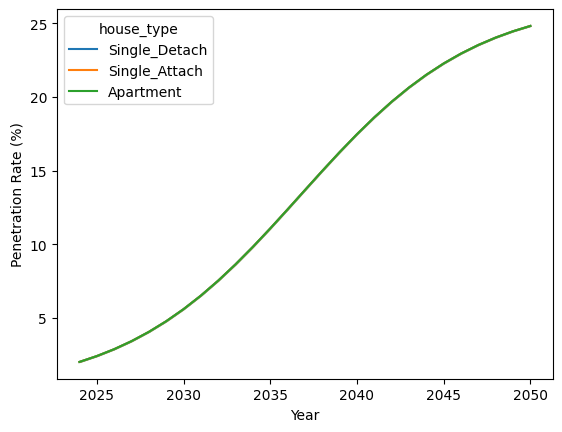

In [16]:
import seaborn as sns
prov = 'Territories'


prov_pen_groups = group_wise_yearly_penetration_rate_forecast_full[
                            (group_wise_yearly_penetration_rate_forecast_full['province']==prov)
                    ]
sns.lineplot(prov_pen_groups, x='Year', y='Penetration Rate (%)', hue='house_type')
prov_pen_groups_year = prov_pen_groups[prov_pen_groups['Year']==2050]

pen_rates = np.array(prov_pen_groups_year.groupby('house_type').mean(numeric_only=True)['Penetration Rate (%)'])
total_houses = prov_pen_groups_year.groupby('house_type').sum()['number_of_houses'] 
from_groups = (prov_pen_groups_year.groupby('house_type').sum()['number_of_houses'] * pen_rates).sum()
from_prov = (prov_pen_groups_year.groupby('house_type').sum()['number_of_houses']).sum() * 60

print(total_houses)
print(prov_pen_groups_year.groupby('house_type').mean(numeric_only=True)['Penetration Rate (%)'])
print("From combining different house_types:", from_groups),
print("From provincial avg of 60%:", from_prov)

house_type
Apartment        1890101
Single_Attach     338759
Single_Detach    1747345
Name: number_of_houses, dtype: int64


0.9168103951154941

In [17]:
group_wise_yearly_penetration_rate_forecast_full.to_csv('../../data/formatted_data/heatpump/hp_penetration_rate_forecast_by_group_all_province.csv')

<Axes: xlabel='Year', ylabel='Penetration Rate (%)'>

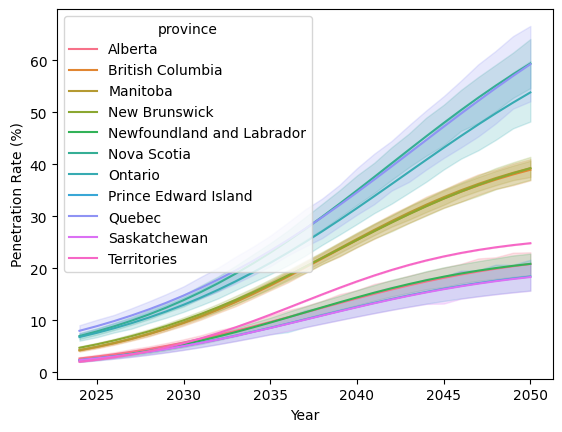

In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
group_wise_yearly_penetration_rate_forecast_full = pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_forecast_by_group_all_province.csv')
group_wise_yearly_penetration_rate_forecast_full.rename(columns={'forecast_year': 'Year', 'hp_penetration_rate': 'Penetration Rate (%)'}, inplace=True)

sns.lineplot(group_wise_yearly_penetration_rate_forecast_full, x='Year', y='Penetration Rate (%)', hue='province')



# Calculating HP Load forecast

In [21]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

## Finding representative houses

In [224]:
# collect the data on representative houses

## Assigning heatpump based on different factors:
- Heated floor area
- Heating and cooling requirement

Use KNN with the above features
  

In [16]:
hp_data_file = '../../data/raw_data/heatpump/ECCC_2023.csv'
hp_data = pd.read_csv(hp_data_file)

C:\Users\konar\AppData\Local\Temp\ipykernel_26972\1487035796.py:2: DtypeWarning: Columns (47,52,87,88,89,151,157,158,183,213,223,227,230,233,256,257,259,275,279,284,326,330,331,347,351,353,358) have mixed types. Specify dtype option on import or set low_memory=False.
  hp_data = pd.read_csv(hp_data_file)


In [323]:
hp_data['count'] = 1
hp_data.groupby(['YEARBUILT', 'HOUSEREGION','BUILDINGTYPE']).count()['count']

YEARBUILT  HOUSEREGION           BUILDINGTYPE              
19         BRITISH COLUMBIA      Multi-unit: whole building     1
160        ALBERTA               House                          1
1634       QUÉBEC                House                          1
1673       QUÉBEC                House                          1
1700       NOVA SCOTIA           House                          1
                                                               ..
2024       ONTARIO               House                         11
                                 Multi-unit: whole building     2
           PRINCE EDWARD ISLAND  House                         31
           SASKATCHEWAN          House                         71
           YUKON                 House                          2
Name: count, Length: 3087, dtype: int64

In [58]:
heatpumpdata = ['HPCAP', 'HPEquipType', 'HPESTAR' ,'HPSOURCE', 'COP']
building_chars = ['HEATEDFLOORAREA', 'BUILDINGTYPE', 'HOUSEID', 'HOUSEREGION', 'YEARBUILT']
location_data = ['HOUSEREGION', 'CLIENTPCODE', 'CLIENTCITY']

thermal_envelope_metrics = ['EGHHLWALLS', 'EGHHLCEILING', 'EGHHLWINDOOR', 'EGHHLFOUND', 'EGHHLEXPOSEDFLR',  'EGHHLAIR']
energy_performance = ['EGHRATING', 'EGHSPACEENERGY', 'ERSENERGYINTENSITY']
energy_consumption_metrics = ['EGHFCONTOTAL' ,'EGHFCONELEC','EGHFCONNGAS','EGHFCONOIL' , 'EGHFCONPROP','EGHFCONWOOD','EGHFCONWOODGJ']
heating_specific_eng_consumption_metrics = ['EGHHEATFCONSE', 
                                            'EGHHEATFCONSG', 
                                            'EGHHEATFCONSO', 
                                            'EGHHEATFCONSP' ,
                                            'EGHHEATFCONSW',
                                            'ERSWATERHEATINGENERGY',
                                            'EGHSPACEENERGY',
                                            'ERSSPACECOOLENERGY']
weather_data = ['WEATHERLOC', 'WTHDATA', 'CoolingSeasonMonths', 'TMAIN', 'QTOT', 'QWARN']
temperature_setting = ['ThermostatCooling', 'ThermostatHeatingNighttime']
time_info = ['CREATIONDATE', 'ENTRYDATE']

#efficiency of the heating equipment

In [17]:
hp_data_with_hp = hp_data.loc[hp_data['HPSOURCE'].isin(['Air', 'Ground', 'Water'])]

In [19]:
feature_cols = ['HEATEDFLOORAREA' , 'EGHSPACEENERGY']

features = np.array(hp_data_with_hp[feature_cols])
values = np.round((np.array(hp_data_with_hp['HPCAP'])/3500 ))



features_int = np.zeros(features.shape)
#features_int[:, 0], buildingtype_dict = convert_str_to_int_for_feat(features[:, 0])
features_int[:, 0] = features[:, 0]
features_int[:, 1] = features[:, 1]



In [31]:
#KNN 

neigh = KNeighborsClassifier(n_neighbors=1000, weights='distance')

neigh.fit(features_int[0:-10000, 0:2], values[0:-10000])
pred_vals = neigh.predict(features_int[-10000:, 0:2])


values_part = values[-10000:] 
print(sum(pred_vals==values_part)/len(values_part))


0.5148


<Axes: xlabel='HPCAP', ylabel='EGHHLAIR'>

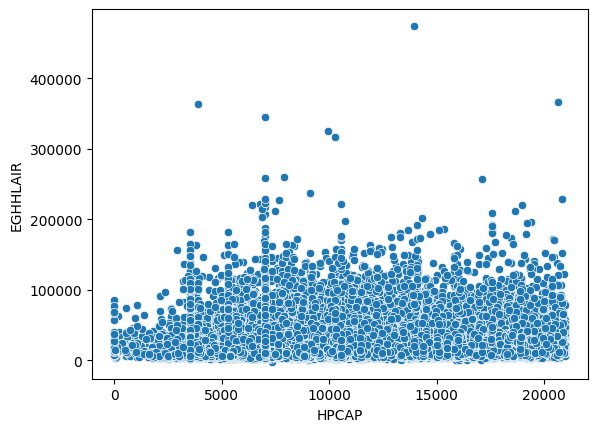

In [183]:
hp_data_with_hp=hp_data_with_hp[hp_data_with_hp['HPCAP']<6*3500] 
sns.scatterplot(hp_data_with_hp[['EGHHLAIR', 'HPCAP']], x='featiPCAP', y='EGHHLAIR' )

## Calculating load

In [ ]:
hp_data_file = '../../data/raw_data/heatpump/ECCC_2023.csv'
hp_data = pd.read_csv(hp_data_file)

In [303]:
hp_data['BUILDINGTYPE']

0                              House
1                              House
2                              House
3                              House
4                              House
                     ...            
506918                         House
506919                         House
506920                         House
506921    Multi-unit: whole building
506922    Multi-unit: whole building
Name: BUILDINGTYPE, Length: 506923, dtype: object

In [245]:
hp_data_with_hp = hp_data.loc[hp_data['HPSOURCE'].isin(['Air', 'Ground', 'Water'])]
feature_cols = ['HEATEDFLOORAREA' , 'EGHSPACEENERGY']

features = np.array(hp_data_with_hp[feature_cols])
values = np.round((np.array(hp_data_with_hp['HPCAP'])/3500 ))

neigh = KNeighborsClassifier(n_neighbors=1000, weights='distance')

neigh.fit(features, values)

KNeighborsClassifier(n_neighbors=1000, weights='distance')

In [37]:
# Its important to use binary mode 
import pickle
#knnPickle = open('../../data/raw_data/heatpump/KNN_HPSIZE_classifier', 'wb') 
      
# source, destination 
#pickle.dump(neigh, knnPickle)  
hp_size_classifier = pickle.load(open('../../data/raw_data/heatpump/KNN_HPSIZE_classifier', 'rb'))
pred_vals = hp_size_classifier.predict(features_int[-10000:, 0:2])


values_part = values[-10000:] 
pred_vals

array([2., 3., 2., ..., 4., 1., 6.])

In [39]:
features_int.shape

(194919, 2)

In [ ]:
import glob
import json
#read the penetration rates for each group
group_penrate_forecast_fname = '../../data/formatted_data/heatpump/hp_penetration_rate_forecast_by_group_all_province.csv'
heatpump_data_fname = '../../data/formatted_data/heatpump/hp_coeff_data_interpolated.json'
norm_heating_pattern = '../../data/formateed_data/heatpump/normalized_24h_heating_pattern.csv'

groupwise_clustering_basefolder = '../../data/formatted_data/heatpump/groupwise_cluster_centers/'
cluster_filename_str = '{0}/{1}/{1}_{2}_{3}_cluster_centers.csv'
feature_cols_KNN = ['HEATEDFLOORAREA' , 'EGHSPACEENERGY']

with open(heatpump_data_fname, 'r') as f:
    heatpump_coeff_interpolated_data = json.load(f)

groupwise_penetration_rate_forecast = pd.read_csv(group_penrate_forecast_fname)
province_name_dict = {
                        'alberta': 'AB', 
                        'british columbia': 'BC',
                        'manitoba': 'MN',
                        'new brunswick': 'NB',
                        'newfoundland and labrador': 'NF',
                        'nova scotia': 'NS', 
                        'ontario': 'ON', 
                        'prince edward island': 'PE', 
                        'quebec': 'QC', 
                        'saskatchewan': 'SK', 
                        'territories': 'Territories'
}
province_list = groupwise_penetration_rate_forecast['province'].unique()
year_of_constrution_list = groupwise_penetration_rate_forecast['year_of_construction'].unique()
house_type_list = groupwise_penetration_rate_forecast['house_type'].unique()
year_list = groupwise_penetration_rate_forecast['forecast_year'].unique()

for province in province_list:
    for year_of_const in year_of_constrution_list:
        for house_type in house_type_list:
            #read the representative house data for each cluster of a group 
            try:
                cluster_pd = pd.read_csv(cluster_filename_str.format(groupwise_clustering_basefolder,
                                                                    province_name_dict[province], 
                                                                     house_type,
                                                                     year_of_const))

                #calculate heating for each representative house in the cluster
                print(cluster_filename_str.format(groupwise_clustering_basefolder,
                                                                    province_name_dict[province], 
                                                                     house_type,
                                                                     year_of_const))
                for _, row in cluster_pd.iterrows():
                    #assign heatpump if absent 
                    if row['HPSOURCE']=='N/A {no Heat Pump}':
                        #assign heatpump
                        row['hp_coeff_data_interpolated'] = 'Air'
                        row['HPCAP'] = neigh.predict(np.array([row[feature_cols_KNN]]))*3500 
                    
                    hourly_electric_usage = get_hourly_electricity_usage_for_house(row, heatpump_coeff_interpolated_data)
                        
                
            except Exception as e:
                #print(f'{cluster_filename_str.format(groupwise_clustering_basefolder, province_name_dict[province], house_type,year_of_const)} was not found.')
                print(e)
                pass




## Plot and verify load forecasting results

<Axes: xlabel='Year', ylabel='Energy required (in TWh)'>

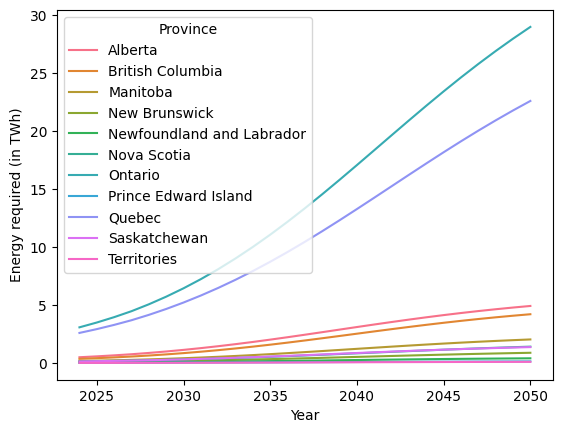

In [13]:
import pandas as pd 
import seaborn as sns

fname = '../../results/heatpump_forecast/electric_energy_n_load_profile_forecast_hp_fixed_penrate.csv'
load_data = pd.read_csv(fname)


load_data['Energy required (in TWh)'] = load_data['total_electric_energy_MWh']/1000000

load_data.rename(columns={'forecast_year': 'Year', 'province':'Province', 'total_electric_energy_MWh': 'Energy required (in MWh)'}, inplace=True)

sns.lineplot(load_data, x='Year', y='Energy required (in TWh)', hue='Province')

In [10]:
load_data[load_data['Province']=='territories']


#load_data[load_data['forecast_year']==2050]['total_electric_energy_MWh'].sum()/1000000*3.6

,Unnamed: 0,Province,Year,Energy required (in MWh),load_profile_24h_mean_MWh,load_profile_24h_mean_MWh.1,load_profile_24h_max_MWh,Energy required (in TWh)
270,0,territories,2024,6178.456490,[0.51756327 0.55432921 0.62869688 0.74634263 0...,[0.51756327 0.55432921 0.62869688 0.74634263 0...,[0.80737269 0.86554488 0.99788632 1.21408227 1...,0.006178
271,1,territories,2025,7453.576383,[0.62438401 0.6687378 0.75845282 0.90037506 1...,[0.62438401 0.6687378 0.75845282 0.90037506 1...,[0.97400798 1.04418569 1.20383693 1.46464257 1...,0.007454
272,2,territories,2026,8963.045098,[0.75083795 0.80417414 0.91205699 1.08271668 1...,[0.75083795 0.80417414 0.91205699 1.08271668 1...,[1.17127021 1.25565985 1.4476394 1.76125145 2...,0.008963
273,3,territories,2027,10735.023167,[0.89928432 0.96316504 1.09237509 1.29676924 1...,[0.89928432 0.96316504 1.09237509 1.29676924 1...,[1.40283966 1.50391277 1.7338422 2.10944234 2...,0.010735
274,4,territories,2028,12871.912751,[1.07830922 1.154906 1.30983405 1.55490427 1...,[1.07830922 1.154906 1.30983405 1.55490427 1...,[1.68211068 1.80330274 2.07899237 2.52933142 2...,0.012872
275,5,territories,2029,15353.578590,[1.28622176 1.3775863 1.56238139 1.85468864 2...,[1.28622176 1.3775863 1.56238139 1.85468864 2...,[2.00644534 2.15100233 2.47983366 3.01696525 3...,0.015354
276,6,territories,2030,18205.336305,[1.52514368 1.63347833 1.85259407 2.19918065 2...,[1.52514368 1.63347833 1.85259407 2.19918065 2...,[2.37915351 2.55055977 2.9404559 3.5773176 4...,0.018205
277,7,territories,2031,21443.735511,[1.79646244 1.92406804 2.18215705 2.59037966 2...,[1.79646244 1.92406804 2.18215705 2.59037966 2...,[2.8023996 3.00429526 3.46353312 4.21363966 4...,0.021444
278,8,territories,2032,25072.894381,[2.10052403 2.24972593 2.55149028 3.02878333 3...,[2.10052403 2.24972593 2.55149028 3.02878333 3...,[3.27672344 3.51278733 4.0497315 4.92673987 5...,0.025073
279,9,territories,2033,29081.213712,[2.43635767 2.6094122 2.95941419 3.51299069 3...,[2.43635767 2.6094122 2.95941419 3.51299069 3...,[3.80061066 4.07441243 4.69717849 5.71433831 6...,0.029081


In [432]:
groupwise_penetration_rate_forecast = pd.read_csv(group_penrate_forecast_fname)
groupwise_penetration_rate_forecast_2024 = groupwise_penetration_rate_forecast[groupwise_penetration_rate_forecast['forecast_year']==2024]
grouped_data_houses = groupwise_penetration_rate_forecast_2024.groupby(['province', 'house_type', 'year_of_construction'], as_index=False)['number_of_houses'].sum()

In [439]:
num_houses = np.sum(
        np.array(groupwise_penetration_rate_forecast_2024['number_of_houses'])* \
            np.array(groupwise_penetration_rate_forecast_2024['hp_penetration_rate']
                    ))
num_houses/100

1140177.5925733054

NameError: name 'ax' is not defined

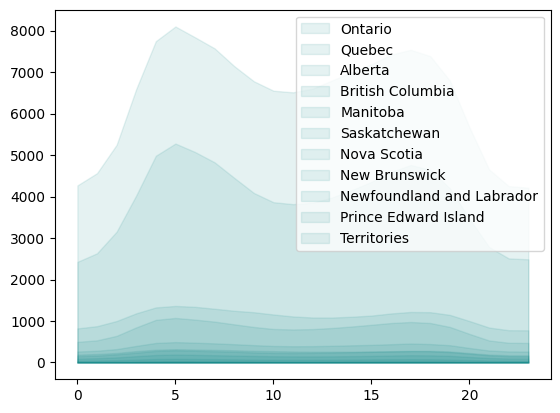

In [6]:
import re
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
load_data = pd.read_csv('../../results/heatpump_forecast/electric_energy_n_load_profile_forecast_hp_fixed_penrate.csv')

col_name = 'load_profile_24h_max_MWh'
year = 2050
provinces = load_data['province'].unique()
provincewise_load_profile = pd.DataFrame()
for province in provinces:
    load_data_province = load_data[(load_data['province']==province) & (load_data['forecast_year']==year)]
    load_data_mean_profile = np.array(load_data_province[col_name])
    array_data = []
    for data in load_data_mean_profile:
        data = data.strip('[]')
        data = re.sub(r'\n', '', data)
        data = data.split(' ')
        #print(len(data))
        array_data.append([val for val in data if len(val)>0])
    array_data = np.array(array_data).astype(float)
    provincewise_load_profile[province] = array_data.mean(axis=0)

#ax = sns.lineplot(provincewise_load_profile)
plot_cols = provincewise_load_profile.columns
prov_load  = np.array(provincewise_load_profile).sum(axis=0)

for i in range(len(prov_col_sort)):

    # Extract data for shading
    # Add shading between the lines
    plt.fill_between(np.arange(24), 
                     np.zeros(24), 
                     provincewise_load_profile[prov_col_sort[i]], color='teal', alpha=0.1, label=prov_col_sort[i])
     

plt.legend()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(xlabel ="Hour of the Day", ylabel = "Electricity MW", title ='24hr Load Profile')

In [5]:
pl = prov_load

prov_col_sort = [ v for _, v in sorted(zip(pl, plot_cols), key=lambda pair:pair[0], reverse=True)]
prov_col_sort

['Ontario',
 'Quebec',
 'Alberta',
 'British Columbia',
 'Manitoba',
 'Saskatchewan',
 'Nova Scotia',
 'New Brunswick',
 'Newfoundland and Labrador',
 'Prince Edward Island',
 'Territories']

In [30]:
# year wise load profile pan canada 
yearwise_load = pd.DataFrame()
for year in range(2025, 2055,5):
    load_data_year = load_data[(load_data['forecast_year']==year)]
    load_data_profile = np.array(load_data_year[col_name])
    array_data = []
    for data in load_data_profile:
        data = data.strip('[]')
        data = re.sub(r'\n', '', data)
        data = data.split(' ')
        #print(len(data))
        array_data.append([val for val in data if len(val)>0])
    array_data = np.array(array_data).astype(float)
    yearwise_load[year] = array_data.mean(axis=0)

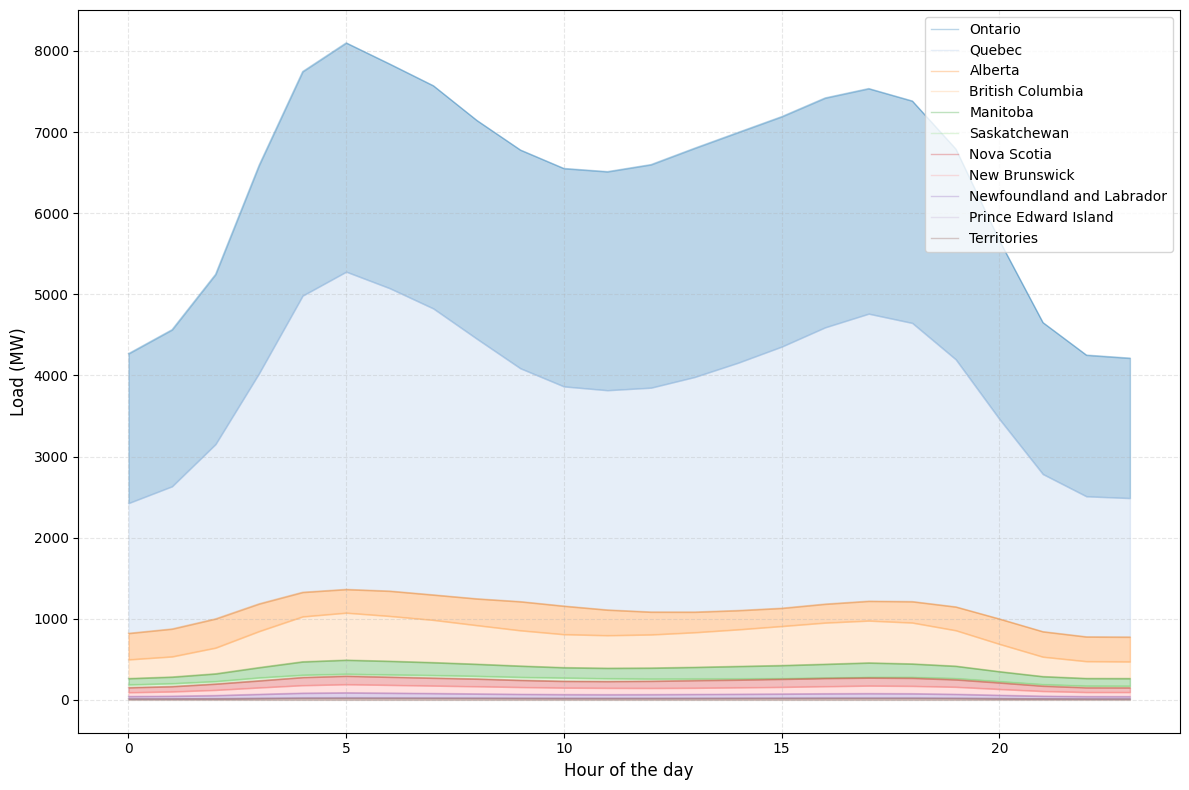

In [21]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def plot_dataframe_lines_with_shading(df, color_palette='viridis', figsize=(12, 8), 
                                      alpha=0.3, title=None, xlabel=None, ylabel=None):
    """
    Plot line curves for each column in a dataframe with shaded areas between adjacent lines.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame where each column is a line to plot and index is the x-axis
    color_palette : str or list
        Name of the seaborn color palette to use or a list of colors
    figsize : tuple
        Figure size as (width, height) in inches
    alpha : float
        Transparency of the shaded areas (0 to 1)
    title : str, optional
        Plot title
    xlabel : str, optional
        Label for x-axis
    ylabel : str, optional
        Label for y-axis
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get colors from the palette
    columns = df.columns
    n_columns = len(columns)
    if isinstance(color_palette, str):
        colors = sns.color_palette(color_palette, n_columns)
    else:
        colors = color_palette
    
    # Sort columns for consistent shading
    sorted_columns = sorted(columns, key=lambda col: df[col].mean(), reverse=True)
    
    # Create x-axis values from the dataframe index
    x = df.index.values
    
    # Plot each line and shade between adjacent lines
    for i, column in enumerate(sorted_columns):
        y = df[column].values
        ax.plot(x, y, color=colors[i], alpha=alpha, label=column, linewidth=1)
        
        # If this is not the last line, shade the area between this line and the next
        if i < len(sorted_columns) - 1:
            next_column = sorted_columns[i + 1]
            next_y = df[next_column].values
            ax.fill_between(x, y, next_y, color=colors[i], alpha=alpha)
        else:
            # For the last line, shade the area between the line and zero
            ax.fill_between(x, y, 0, color=colors[i], alpha=alpha)
    
    # Set labels and title
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)
    
    # Add a legend
    plt.legend()
    
    # Make the plot look nicer
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.grid(True, linestyle='--')
    
    return fig, ax

# Example usage:
if __name__ == "__main__":
    # Create sample data
    np.random.seed(42)
    dates = pd.date_range('2023-01-01', periods=50)
    data = {
        'Series A': np.random.normal(20, 5, 50).cumsum(),
        'Series B': np.random.normal(15, 4, 50).cumsum(),
        'Series C': np.random.normal(10, 3, 50).cumsum(),
        'Series D': np.random.normal(5, 2, 50).cumsum()
    }
    df = pd.DataFrame(data, index=dates)
    
    # Plot with different color palettes
    plot_dataframe_lines_with_shading(provincewise_load_profile, color_palette='tab20', alpha=0.3,
                                     title='',
                                     xlabel='Hour of the day', ylabel='Load (MW)')
    plt.show()

# Overload assessment

For overload assessment we need to do the following:

- HP penetration rate
- Heating Energy requirement
- Avg HP size
- What are the backup systems being used
- Reduce the load from the fraction of houses that switch from electricity to heatpump
- Change the total number of houses based on population
  

### Find representative home

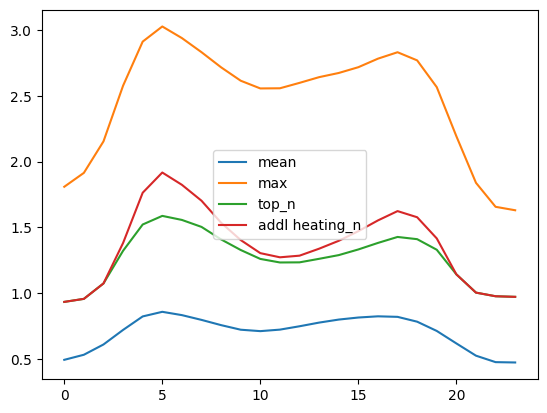

In [65]:
import matplotlib.pyplot as plt
rephouse_data_fname = '../data/heatpump/representative_houses/qc_mean_representative_house_heating_cooling_stats.csv'

res_energy_24h_norm = np.array(pd.read_excel('../data/nonEV_norm.xlsx')['residential'])
res_multiplier = 0.48 *  1.011**10 *1000 #converting MWH to KWH
rephouse_data = pd.read_csv(rephouse_data_fname)
max_heatload_day = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24).sum(axis=1).argmax()
top_n_ind = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24).sum(axis=1).argpartition(2)[-2:]
top_n_heatload_day = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24)[top_n_ind, :].mean(axis=0)

rephouse_data_daily_energy_mean = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24).mean(axis=0)

rephouse_data_daily_energy_max = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24)[max_heatload_day, :]
rephouse_data_daily_additional_energy_mean_kj = np.array(rephouse_data['heating_load_additional_KJ']+rephouse_data['cooling_load_additional_KJ']).reshape(-1, 24)[top_n_ind, :].mean(axis=0)
res_energy_24h = res_energy_24h_norm * res_multiplier
#plt.plot(res_energy_24h)
#plt.plot(rephouse_data_daily_energy_max*15)
plt.plot(rephouse_data_daily_energy_mean, label='mean')
plt.plot(rephouse_data_daily_energy_max, label='max')
plt.plot(top_n_heatload_day, label='top_n')
plt.plot(rephouse_data_daily_additional_energy_mean_kj/3600 + top_n_heatload_day, label='addl heating_n')
plt.legend()

In [66]:
rephouse_data

,Unnamed: 0,heating_load_KWh,heating_load_additional_KJ,cooling_load_KWh,cooling_load_additional_KJ,heating_COP,cooling_COP,hourly_temp,province,fsa
0,0,0.555631,-4.134067e-14,0.0,0.0,2.375662,0.0,4.908318,QUÉBEC,G3E
1,1,0.612020,-8.268134e-14,0.0,0.0,2.371476,0.0,4.812864,QUÉBEC,G3E
2,2,0.731531,-8.268134e-14,0.0,0.0,2.399407,0.0,4.594682,QUÉBEC,G3E
3,3,0.803148,-1.653627e-13,0.0,0.0,2.757687,0.0,4.417409,QUÉBEC,G3E
4,4,0.992014,7.764135e+01,0.0,0.0,2.705934,0.0,4.253773,QUÉBEC,G3E
...,...,...,...,...,...,...,...,...,...,...
8779,8779,1.383794,3.563977e+02,0.0,0.0,2.200952,0.0,-2.446227,QUÉBEC,G3E
8780,8780,1.182278,0.000000e+00,0.0,0.0,2.160608,0.0,-2.996227,QUÉBEC,G3E
8781,8781,1.012678,-1.653627e-13,0.0,0.0,1.864156,0.0,-3.328045,QUÉBEC,G3E
8782,8782,0.993795,1.860330e-13,0.0,0.0,1.713265,0.0,-3.323500,QUÉBEC,G3E


### Calculate electric load from Electricity Baseboard

In [12]:

def electricity_requirement_for_house_heating_cooling(rephouse_data, primary_heating_type, secondary_heating_type, top_n=3):
    '''
    Given the annual hourly heating and cooling data of a house, this method calculates the mean 24hr electric load profile 
    of that given house base on the type of heating method used.
    rep_house_data: Dataframe containing 
                        heating_load_KWh 	
                        heating_load_additional_KJ 	
                        cooling_load_KWh 	'
                        cooling_load_additional_KJ 	
                        heating_COP 	
                        cooling_COP 	
    primary_heating_type: str: ['hp', 'electric', 'gas']
    secondary_heating_type: str: ['electric', 'gas'] #only applicable with 'hp' as primary_heating_type

    returns a 24hr load profile: array of size 24
    '''
    if primary_heating_type!='hp':
        secondary_heating_type=primary_heating_type


    top_n_ind = np.array(rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']).reshape(-1, 24).sum(axis=1).argpartition(top_n)[-top_n:]

    if primary_heating_type=='hp':
        rephouse_data_daily_electric_energy_mean_kwh = np.array(
                            rephouse_data['heating_load_KWh']+rephouse_data['cooling_load_KWh']
                                    ).reshape(-1, 24)[top_n_ind, :].mean(axis=0)
        
    elif primary_heating_type=='electric':
        #electric has a COP of 1
        rephouse_data_daily_electric_energy_mean_kwh = (
                np.array(rephouse_data['heating_load_KWh'])*np.array(rephouse_data['heating_COP']) + \
                np.array(rephouse_data['cooling_load_KWh'])*np.array(rephouse_data['cooling_COP'])
                                    ).reshape(-1, 24)[top_n_ind, :].mean(axis=0)
    else:
        rephouse_data_daily_electric_energy_mean_kwh = np.zeros(24)
    
    if secondary_heating_type=='electric':
    
        rephouse_data_daily_additional_energy_mean_kj = np.array(
                        rephouse_data['heating_load_additional_KJ']+rephouse_data['cooling_load_additional_KJ']
                            ).reshape(-1, 24)[top_n_ind, :].mean(axis=0)
        rephouse_data_daily_additional_energy_mean_kwh = rephouse_data_daily_additional_energy_mean_kj/3600
        
    else:
        rephouse_data_daily_additional_energy_mean_kwh = np.zeros(24)
    
    return rephouse_data_daily_electric_energy_mean_kwh + rephouse_data_daily_additional_energy_mean_kwh



74.42607592694722
34.35918386111102
29.691478952171277


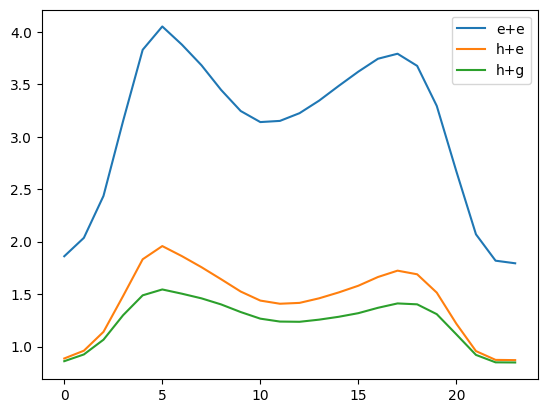

In [76]:
primary_heating_type = 'electric'
secondary_heating_type = 'electric'

rephouse_data_fname = '../data/heatpump/representative_houses/canada_mean_representative_house_heating_cooling_stats.csv'
rephouse_data = pd.read_csv(rephouse_data_fname)
out1 = electricity_requirement_for_house_heating_cooling(rephouse_data, primary_heating_type, secondary_heating_type, top_n=3)
print(out1.sum())
plt.plot(out1, label = f'e+e')
out1 = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp' , 'electric' , top_n=3)
print(out1.sum())
plt.plot(out1, label = f'h+e')
out1 = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'gas', top_n=3)
print(out1.sum())
plt.plot(out1, label = f'h+g')

plt.legend()

In [85]:
(34*0.35+29*0.65)/(74*0.35+34*0.054)

1.1086674358234787

88.4

### Calculate the number of houses of different heating types in representative network 

In [18]:
row_new_list = []
for i, row in group_penrate_forecast.iterrows():
    extra_houses = row['number_of_houses']*row['Penetration Rate (%)']/100 + row['electric'] + row['non_electric'] - row['number_of_houses']
    #print(extra_houses)
    elec_frac = row['electric']/(row['non_electric']+row['electric'])
    row['electric'] = row['electric'] - int(extra_houses*elec_frac)
    row['non_electric'] = row['non_electric'] - int(extra_houses*(1-elec_frac))
    row_new_list.append(row)

In [206]:
import numpy as np 
import pandas as pd
group_penrate_forecast_fname = '../../data/formatted_data/heatpump/hp_penetration_rate_forecast_by_group_all_province.csv'
group_penrate_forecast = pd.read_csv(group_penrate_forecast_fname)
group_penrate_forecast[group_penrate_forecast['Year']==2024]['non_electric'].mean()


24695.0826446281

In [23]:
import numpy as np 
import pandas as pd
years = list(np.arange(2025, 2055, 5))
years.insert(0,2024)
house_ratio = pd.DataFrame(columns=['year', 'hp', 'hp_from_electric', 'hp_from_gas', 'electric', 'gas'])
hp_list = []
electric_list = []
gas_list = []

for year in years:
    group_penrate_forecast_year = group_penrate_forecast[group_penrate_forecast['Year']==year]
    total_houses = group_penrate_forecast_year['number_of_houses'].sum()
    houses_with_electric = group_penrate_forecast_year['electric'].sum()
    houses_with_nonelectric = group_penrate_forecast_year['non_electric'].sum()
    houses_with_hp = (np.array(group_penrate_forecast_year['number_of_houses']) * \
                          np.array(group_penrate_forecast_year['Penetration Rate (%)'])).sum()/100
    
    #adjust the number of other houses
    if len(hp_list) > 0:
        print('here')
        base_hp_num = hp_list[0]*total_houses
        inc_in_hp = houses_with_hp - base_hp_num
        change_ratio = 3 #3 gas houses to 1 electric houses would change to HP
        houses_with_electric-= inc_in_hp/(change_ratio+1)
        houses_with_nonelectric -= inc_in_hp*change_ratio/(change_ratio+1)
    
    print(total_houses, houses_with_electric+houses_with_nonelectric+houses_with_hp)
    hp_list.append(houses_with_hp/total_houses)
    electric_list.append(houses_with_electric/total_houses)
    gas_list.append(houses_with_nonelectric/total_houses)
    
house_ratio['year'] = years
house_ratio['hp'] = hp_list
house_ratio['electric'] = electric_list
house_ratio['gas'] = gas_list
house_ratio['hp_from_electric'] = 1/(change_ratio+1)
house_ratio['hp_from_gas'] = change_ratio/(change_ratio+1)

house_ratio.to_csv('../data/heatpump/representative_houses/ratio_of_housetypes_in_network.csv')

15903856 16053460.76794823
here
15903856 16053460.767948229
here
15903856 16053460.767948233
here
15903856 16053460.767948229
here
15903856 16053460.767948233
here
15903856 16053460.767948229
here
15903856 16053460.767948229


In [114]:
np.array(house_ratio[house_ratio['year']==2024][['hp', 'electric', 'gas']]).sum()
house_ratio

,year,hp,hp_from_electric,hp_from_gas,electric,gas
0,2024,0.062318,0.25,0.75,0.382313,0.563657
1,2025,0.070425,0.25,0.75,0.380286,0.557576
2,2030,0.125501,0.25,0.75,0.366517,0.516269
3,2035,0.206456,0.25,0.75,0.346278,0.455553
4,2040,0.304578,0.25,0.75,0.321748,0.381962
5,2045,0.399266,0.25,0.75,0.298076,0.310946
6,2050,0.472903,0.25,0.75,0.279666,0.255718


In [22]:
np.array(house_ratio[house_ratio['year']==2024][['hp', 'electric', 'gas']]).sum()
house_ratio

,year,hp,hp_from_electric,hp_from_gas,electric,gas
0,2024,0.063437,0.25,0.75,0.382313,0.563657
1,2025,0.071270,0.25,0.75,0.380355,0.557783
2,2030,0.124341,0.25,0.75,0.367087,0.517979
3,2035,0.203678,0.25,0.75,0.347253,0.458476
4,2040,0.304884,0.25,0.75,0.321951,0.382571
5,2045,0.411690,0.25,0.75,0.295250,0.302467
6,2050,0.505347,0.25,0.75,0.271835,0.232224


### Calculate the non heating residential load

Avg Energy per house: 32. For 15 houses: 480.
Avg non heating per house: 16.742679127725857. For 15 houses: 251.14018691588785.
752.1985471358869 725.1450931199975


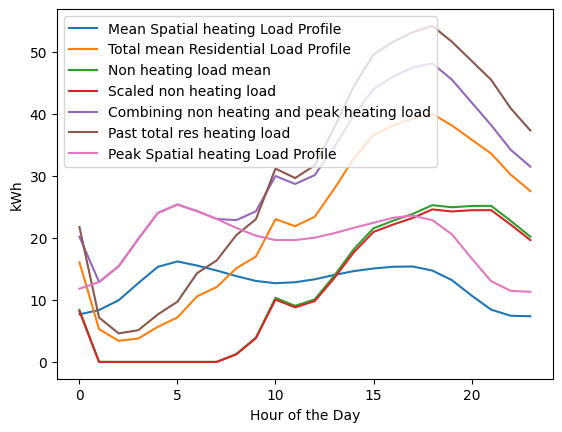

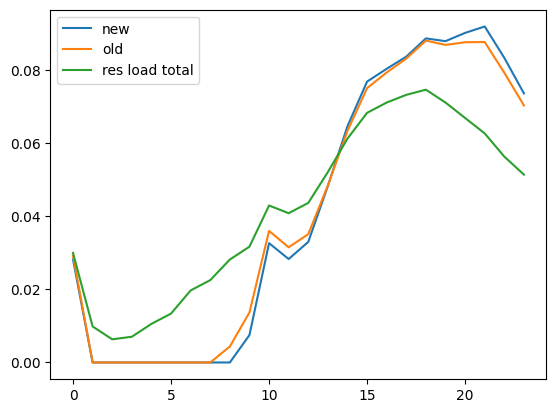

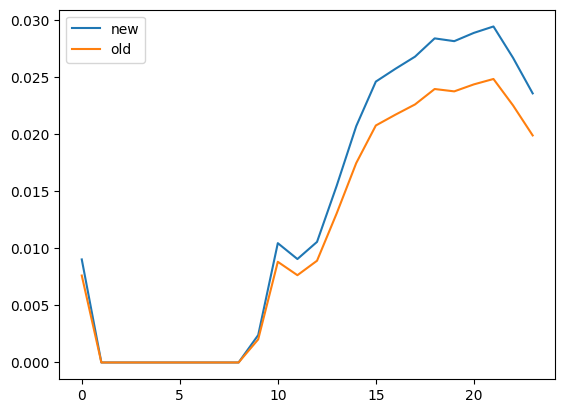

In [30]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
house_ratio_fname = '../data/heatpump/representative_houses/ratio_of_housetypes_in_network_across_years.csv'
#rephouse_data_fname = '../data/heatpump/representative_houses/quebec_representative_house_heating_cooling_stats_0.csv'
rephouse_data_fname = '../data/heatpump/representative_houses/canada_mean_representative_house_heating_cooling_stats.csv'

avg_energy = 32
non_heat_mult = (209+74+52.9)/(209+74+41.5+53+264.5)
print(f"Avg Energy per house: {avg_energy}. For 15 houses: {avg_energy*15}.")
print(f"Avg non heating per house: {avg_energy*non_heat_mult}. For 15 houses: {avg_energy*15*non_heat_mult}.")
      

house_ratio = pd.read_csv(house_ratio_fname)
rephouse_data = pd.read_csv(rephouse_data_fname)

non_ev_norm_loads_new = pd.read_excel('../data/nonEV_norm_without_heating.xlsx')

non_ev_norm_load = pd.read_excel('../data/nonEV_norm.xlsx')
res_energy_24h_norm = np.array(pd.read_excel('../data/nonEV_norm.xlsx')['residential'])
res_multiplier_mean = 0.48 *  1.011**10 *1000 #converting MWH to KWH
res_multiplier = 0.65 * 1.011**10 *1000
res_energy_24h_mean = res_energy_24h_norm * res_multiplier_mean
res_energy_24h_past = res_energy_24h_norm * res_multiplier


# mean heating load 
hp_house_with_gas_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'gas', 365)
hp_house_with_electric_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'electric', 365)
electric_house_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'electric', 'gas', 365)

year = 2025
electric_frac = house_ratio[house_ratio['year']==year]['electric'].item()
gas_frac = house_ratio[house_ratio['year']==year]['gas'].item()

num_houses = 15
hp_with_electric = hp_house_with_electric_load_profile* \
                        house_ratio[house_ratio['year']==year]['hp'].item()* \
                            house_ratio[house_ratio['year']==year]['hp_from_electric'].item()
hp_with_gas = hp_house_with_gas_load_profile* \
                house_ratio[house_ratio['year']==year]['hp'].item()* \
                    house_ratio[house_ratio['year']==year]['hp_from_gas'].item()
electric = electric_house_load_profile*house_ratio[house_ratio['year']==year]['electric'].item()

total_heating_load_mean = (hp_with_electric + hp_with_gas + electric ) * num_houses
non_heating_load = np.maximum(0, res_energy_24h_mean-total_heating_load_mean)
non_heating_load_norm = non_heating_load/non_heating_load.sum()

non_heating_load_scaled = non_heating_load_norm * 0.25 * 1.011**10 * 1000

plt.plot(total_heating_load_mean, label='Mean Spatial heating Load Profile')
plt.plot(res_energy_24h_mean, label='Total mean Residential Load Profile')
plt.plot(non_heating_load, label='Non heating load mean')
plt.plot(non_heating_load_scaled, label='Scaled non heating load')
# peak heating load 

hp_house_with_gas_load_profile_peak = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'gas', 14)
hp_house_with_electric_load_profile_peak = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'electric', 14)
electric_house_load_profile_peak = electricity_requirement_for_house_heating_cooling(rephouse_data, 'electric', 'gas', 14)

year = 2025
electric_frac = house_ratio[house_ratio['year']==year]['electric'].item()
gas_frac = house_ratio[house_ratio['year']==year]['gas'].item()

num_houses = 15
hp_with_electric_peak = hp_house_with_electric_load_profile_peak* \
                        house_ratio[house_ratio['year']==year]['hp'].item()* \
                            house_ratio[house_ratio['year']==year]['hp_from_electric'].item()
hp_with_gas_peak = hp_house_with_gas_load_profile_peak* \
                house_ratio[house_ratio['year']==year]['hp'].item()* \
                    house_ratio[house_ratio['year']==year]['hp_from_gas'].item()
electric_peak = electric_house_load_profile_peak*house_ratio[house_ratio['year']==year]['electric'].item()

total_heating_load_peak = (hp_with_electric_peak + hp_with_gas_peak + electric_peak ) * num_houses


# plt.plot(hp_house_with_gas_load_profile, label='hp+gas')
# plt.plot(hp_house_with_electric_load_profile, label='hp+elec')
# plt.plot(electric_house_load_profile, label='electric')...



plt.plot(non_heating_load+total_heating_load_peak, label='Combining non heating and peak heating load')
plt.plot(res_energy_24h_past, label='Past total res heating load')
plt.plot(total_heating_load_peak, label='Peak Spatial heating Load Profile')

print((non_heating_load+total_heating_load_peak).sum(), res_multiplier)

plt.xlabel('Hour of the Day')
plt.ylabel('kWh')
plt.legend()


new_non_heating_load = np.maximum(0, res_energy_24h_past - total_heating_load_peak)

new_non_heating_load_norm = new_non_heating_load/new_non_heating_load.sum()
plt.figure()
plt.plot(new_non_heating_load_norm, label='new')
plt.plot(non_heating_load_norm, label='old')
plt.plot(res_energy_24h_norm, label='res load total')
plt.legend()

plt.figure()
plt.plot(new_non_heating_load_norm*0.32, label='new')
plt.plot(new_non_heating_load_norm*0.27, label='old')

plt.legend()



In [43]:
non_heating_load.sum(), 0.25*1.01**10, total_heating_load_peak.sum(), (res_energy_24h_past - total_heating_load_peak).sum()


(286.73933436476887, 0.27615553135280113, 465.4592127711179, 271.7307487961732)

## Checking the partial loading theory

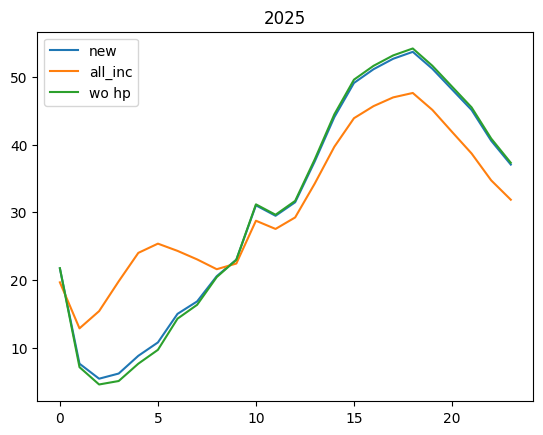

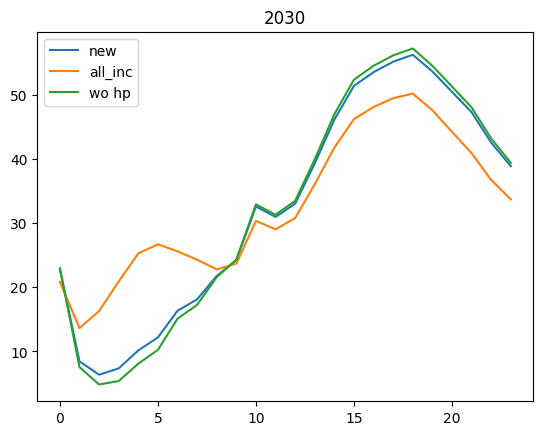

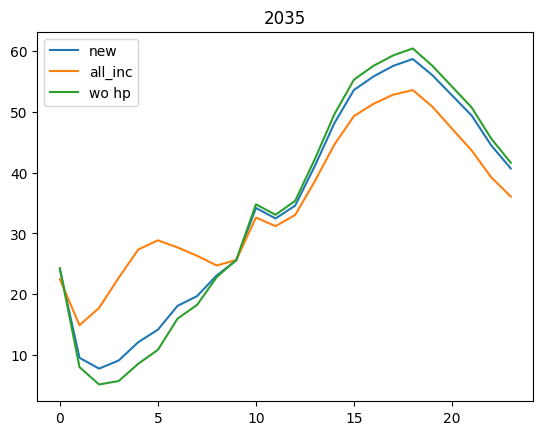

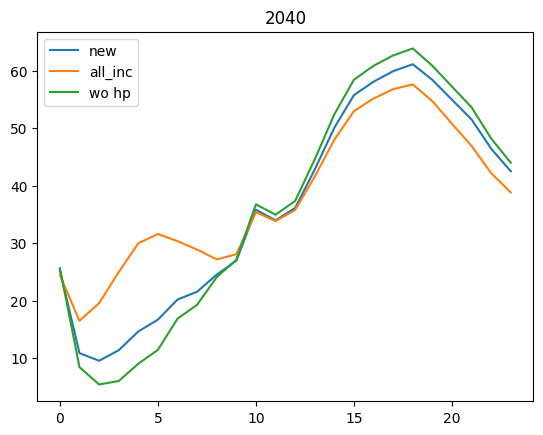

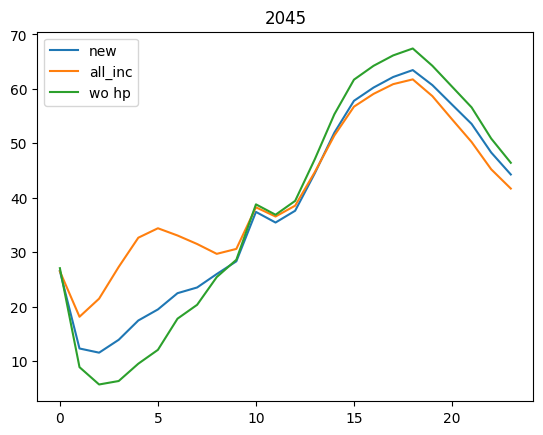

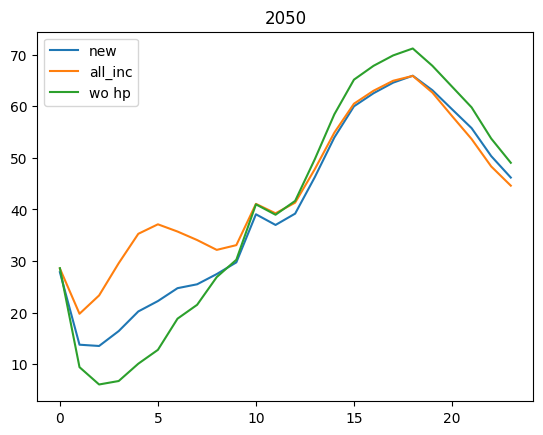

<Figure size 640x480 with 0 Axes>

In [44]:
import pandas as pd 
import seaborn as sns

rephouse_data_fname = '../data/heatpump/representative_houses/canada_mean_representative_house_heating_cooling_stats.csv'
pop_growth = pd.read_csv('../data/ldev_load_data/population_change_diff_areas.csv') #in fraction

norm_loads = pd.read_csv('../data/nonEV_norm_without_heating.csv')
house_ratio = pd.read_csv('../data/heatpump/representative_houses/ratio_of_housetypes_in_network_across_years.csv')
rephouse_data = pd.read_csv(rephouse_data_fname)


non_heating_res_multiplier = 0.25* 1.011**10 * 1000
heating_res_multiplier = 0.65* 1.011**10 * 1000
k = 1.011**5

res_energy_24h_norm = norm_loads['residential']
res_non_heating_energy_24h_norm = norm_loads['residential_wo_heating_uoft']

year_load_dict = pd.DataFrame()
num_houses = 15
growth_rate_from_pop = 1
for year in range(2025, 2055, 5):
    
    # from only considering HP 
    hp_house_with_gas_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'gas', 14)
    hp_house_with_electric_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'hp', 'electric', 14)
    electric_house_load_profile = electricity_requirement_for_house_heating_cooling(rephouse_data, 'electric', 'gas', 14)
    
    hp_with_electric = hp_house_with_electric_load_profile* \
                            house_ratio[house_ratio['year']==year]['hp'].item()* \
                                house_ratio[house_ratio['year']==year]['hp_from_electric'].item()
    hp_with_gas = hp_house_with_gas_load_profile* \
                    house_ratio[house_ratio['year']==year]['hp'].item()* \
                        house_ratio[house_ratio['year']==year]['hp_from_gas'].item()

    electric = electric_house_load_profile*house_ratio[house_ratio['year']==year]['electric'].item()

    
    hp_ratio = house_ratio[house_ratio['year']==year]['hp'].item()
    
    hp_house_non_heating_load = res_non_heating_energy_24h_norm * non_heating_res_multiplier * hp_ratio
    hp_house_heating_load  = (hp_with_electric + hp_with_gas ) * num_houses

    res_load_from_rest = res_energy_24h_norm * heating_res_multiplier * (1 - hp_ratio)

    total_load_res_bus = res_load_from_rest + hp_house_non_heating_load  + (hp_house_heating_load) * growth_rate_from_pop
    plt.plot(total_load_res_bus, label='new')

    #from past load calculation
    total_heating_load_old = (hp_with_electric + hp_with_gas + electric ) * num_houses
    total_non_heating_load_old = res_non_heating_energy_24h_norm * non_heating_res_multiplier
    total_load_res_bus_old = total_non_heating_load_old + (total_heating_load_old) * growth_rate_from_pop
    plt.plot(total_load_res_bus_old, label = 'all_inc')

    plt.plot(res_energy_24h_norm*heating_res_multiplier, label='wo hp')
    plt.legend()
    plt.title(year)
    plt.figure()
    growth_rate_from_pop = pop_growth[(pop_growth['year']==year) & (pop_growth['area']=='urban')]['rel_pop_change_frac'].item()
    non_heating_res_multiplier*=k
    heating_res_multiplier*=k


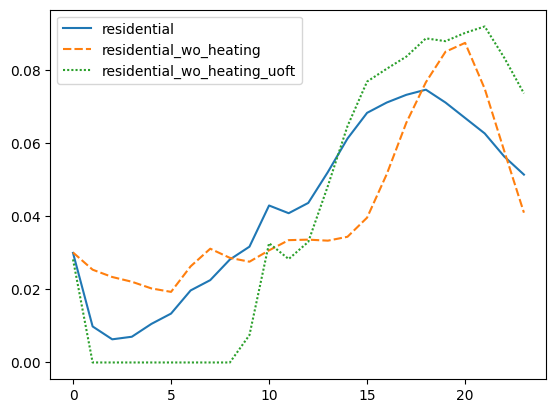

In [37]:
norm_loads_past = pd.read_excel('../data/nonEV_norm.xlsx')

norm_loads['residential'] = norm_loads_past['residential']

sns.lineplot(norm_loads[['residential', 'residential_wo_heating', 'residential_wo_heating_uoft']])

norm_loads.to_csv('../data/nonEV_norm_without_heating.csv')

In [7]:
pd.read_csv('../data/ldev_load_data/population_change_diff_areas.csv') #in fraction


,area,year,rel_pop_change_frac
0,urban,2023,1.000000
1,urban,2024,1.024747
2,urban,2025,1.031777
3,urban,2026,1.038835
4,urban,2027,1.045648
...,...,...,...
79,rural,2046,1.267815
80,rural,2047,1.278282
81,rural,2048,1.288559
82,rural,2049,1.298862


3.2315300799094526 3.208654355390696


<Axes: >

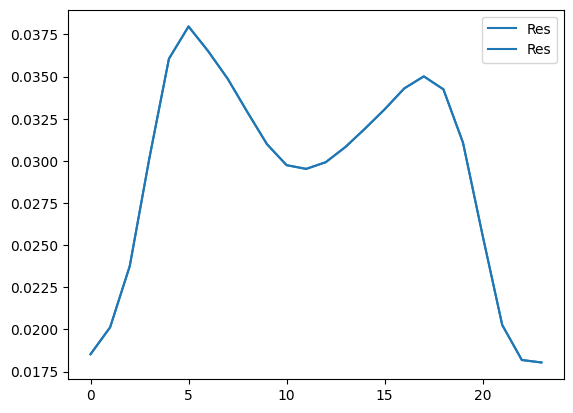

In [205]:
old_peak = (non_heating_load/non_heating_load.sum()).max()*1.011**35
new_peak = non_ev_norm_loads_new['residential_wo_heating'].max()*1.011**35
print(old_peak, new_peak)

heating_load2 = pd.read_csv('../results/results_new_all_inc2/Results_ldev_load_data_EV_load_profiles_daily_req_urban/2050_space_heat_cool_load.csv')

heating_load = pd.read_csv('../results/results_new_all_inc/Results_ldev_load_data_EV_load_profiles_daily_req_urban/2050_space_heat_cool_load.csv')

sns.lineplot(heating_load.drop(columns=['Unnamed: 0']))                       
sns.lineplot(heating_load2.drop(columns=['Unnamed: 0']))                       


In [83]:
(res_energy_24h+total_heating_load).sum(), res_energy_24h_past.sum()

(741.6672561683731, 737.1899615672912)

In [26]:
(209+74+52.9)/(209+74+41.5+53+264.5)

0.523208722741433

In [161]:
hp_house_with_electric_load_profile.sum(), electric_house_load_profile.sum(), electric_frac, gas_frac

(35.86191717369407, 76.32556172634392, 0.3803547202285409, 0.5577825967680418)

In [51]:
house_ratio[house_ratio['year']==year]

,Unnamed: 0,year,hp,hp_from_electric,hp_from_gas,electric,gas
1,1,2025,0.07127,0.25,0.75,0.380355,0.557783


In [59]:
0.72/15*1000

48.0

### Cross checking load results

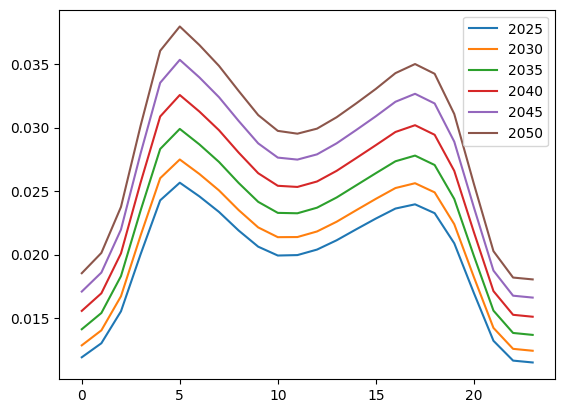

In [6]:
import glob
import numpy as np
import matplotlib.pyplot as plt
pop_growth = pd.read_csv('../data/ldev_load_data/population_change_diff_areas.csv') #in fraction
base_folder = '../results/results_new_all_inc/Results_ldev_load_data_EV_load_profiles_daily_req_urban'

norm_load = pd.read_excel('../data/nonEV_norm_without_heating.xlsx')

res_wo = 0.22 * 1.011**10 
res = 0.48 * 1.011**10 
k = 1.011**5

for year in range(2025, 2055, 5):
    load_file = glob.glob(f'{base_folder}/{year}_space_heat_cool_load.csv')

    heat_load = np.array(pd.read_csv(load_file[0])['Res'])
    non_heat_load = np.array(norm_load['residential_wo_heating']) * res_wo
    res_load = np.array(norm_load['residential']) * res
    res*=k
    res_wo*=k
    plt.plot(heat_load, label=year)
    #plt.plot(res_load, label='old total')
    #plt.title()
    plt.legend()
    #plt.show()
    
    

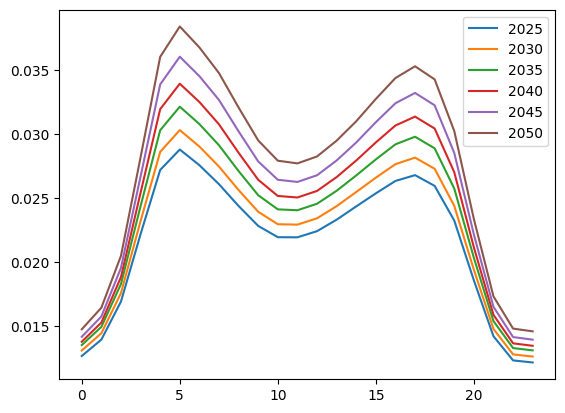

In [156]:
import glob
pop_growth = pd.read_csv('../data/ldev_load_data/population_change_diff_areas.csv') #in fraction
base_folder = '../results_new/Results_base_suburban'

norm_load = pd.read_excel('../data/nonEV_norm_without_heating.xlsx')

res_wo = 0.22 * 1.011**10 
res = 0.48 * 1.011**10 
k = 1.011**5

for year in range(2025, 2055, 5):
    load_file = glob.glob(f'{base_folder}/{year}_space_heat_cool_load.csv')

    heat_load = np.array(pd.read_csv(load_file[0])['Res'])
    non_heat_load = np.array(norm_load['residential_wo_heating']) * res_wo
    res_load = np.array(norm_load['residential']) * res
    res*=k
    res_wo*=k
    plt.plot(heat_load, label=year)
    #plt.plot(res_load, label='old total')
    #plt.title()
    plt.legend()
    #plt.show()

In [115]:
0.73/1.011**10

0.654351804214001

In [118]:
0.66*1.011**10

0.7363011714756896

## Checking US load profile data

In [189]:
import glob 
base_folder = '../data/heatpump/us_load_data/Residential/'
fnames = glob.glob(f'{base_folder}/*/*.csv')
full_load_df = pd.DataFrame()
for fname in fnames:
    load_data_df = pd.read_csv(fname)
    full_load_df = pd.concat([full_load_df, load_data_df]) 



In [150]:
full_load_df.columns

Index(['Date/Time', 'Electricity:Facility [kW](Hourly)',
       'Fans:Electricity [kW](Hourly)', 'Cooling:Electricity [kW](Hourly)',
       'Heating:Electricity [kW](Hourly)',
       'InteriorLights:Electricity [kW](Hourly)',
       'InteriorEquipment:Electricity [kW](Hourly)',
       'Gas:Facility [kW](Hourly)', 'Heating:Gas [kW](Hourly)',
       'InteriorEquipment:Gas [kW](Hourly)',
       'Water Heater:WaterSystems:Gas [kW](Hourly)',
       'Electricity:Facility [kW](Monthly)', 'Gas:Facility [kW](Monthly)'],
      dtype='object')

In [156]:
import matplotlib.pyplot as plt
# electric_load = full_load_df['Electricity:Facility [kW](Hourly)'] - \
#                     (full_load_df['Heating:Electricity [kW](Hourly)'] + \
#                      full_load_df['Cooling:Electricity [kW](Hourly)'] + \
#                      full_load_df['Water Heater:WaterSystems:Electricity [kW](Hourly) ']
#                      )

# mean_load_df = full_load_df.groupby('Date/Time').mean()[['Electricity:Facility [kW](Hourly)', 
#                                                          'Heating:Electricity [kW](Hourly)', 
#                                                          'Cooling:Electricity [kW](Hourly)',
#                                                         'Water Heater:WaterSystems:Electricity [kW](Hourly) ',
#                                                         'HVACFan:Fans:Electricity [kW](Hourly)', 
#                                                         'Fans:Electricity [kW](Hourly)']]
#mean_load_df = full_load_df.groupby('Date/Time').mean()['Electricity:Facility [kW](Hourly)']

In [144]:


mean_load = mean_load_df['Electricity:Facility [kW](Hourly)'] - \
                    (mean_load_df['Heating:Electricity [kW](Hourly)'] + \
                     mean_load_df['Cooling:Electricity [kW](Hourly)'] + \
                     mean_load_df['Water Heater:WaterSystems:Electricity [kW](Hourly) '] + \
                     mean_load_df['HVACFan:Fans:Electricity [kW](Hourly)'] + \
                     mean_load_df['Fans:Electricity [kW](Hourly)']
                     )

In [154]:
mean_load_df

Date/Time
 01/01  01:00:00    112.410069
 01/01  02:00:00    111.233996
 01/01  03:00:00    109.901706
 01/01  04:00:00    109.417581
 01/01  05:00:00    112.151096
                       ...    
11/12  24:00:00     265.280730
12/10  02:00:00      15.434440
12/22  08:00:00      24.242326
12/23  15:00:00      34.344144
12/31  09:00:00      14.465124
Name: Electricity:Facility [kW](Hourly), Length: 8796, dtype: float64

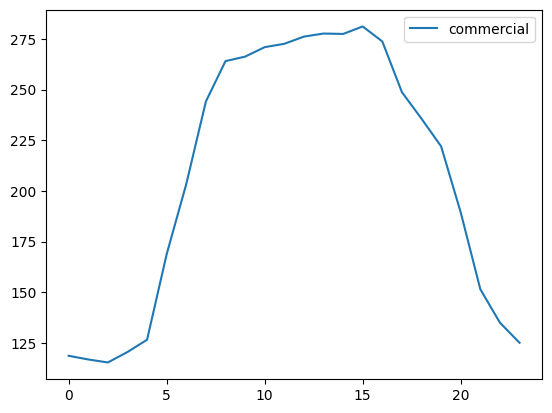

In [159]:
load_mean_line= np.array(mean_load_df)[0:8760].reshape(-1, 24).mean(axis=0)

#total_mean_load_line =  np.array(mean_load_df['Electricity:Facility [kW](Hourly)'])[0:8760].reshape(-1, 24).mean(axis=0)
plt.plot(load_mean_line, label='commercial')
#plt.plot(total_mean_load_line, label='w heating')
#plt.plot(total_mean_load_line-load_mean_line, label='heating')
plt.legend()

In [146]:
mean_load_pd = pd.DataFrame()
mean_load_pd['wo_heating'] = load_mean_line
mean_load_pd['heating'] = total_mean_load_line-load_mean_line
mean_load_pd['w_heating'] = total_mean_load_line
mean_load_pd.to_csv('./us_24h_load_data.csv')

In [139]:
mean_load_df.iloc[0:24]

,Electricity:Facility [kW](Hourly),Heating:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Water Heater:WaterSystems:Electricity [kW](Hourly)
Date/Time,,,,
01/01 01:00:00,1.025701,0.115137,0.0,0.144952
01/01 02:00:00,0.907576,0.133242,0.0,0.090676
01/01 03:00:00,0.876387,0.149680,0.0,0.076028
01/01 04:00:00,0.881773,0.162366,0.0,0.080232
01/01 05:00:00,0.910538,0.173228,0.0,0.123941
01/01 06:00:00,1.041985,0.177606,0.0,0.313130
01/01 07:00:00,1.438724,0.215478,0.0,0.667714
01/01 08:00:00,1.762246,0.187912,0.0,0.767461
01/01 09:00:00,1.656227,0.141375,0.0,0.746048


In [125]:
8760 /24

365.875

<Axes: >

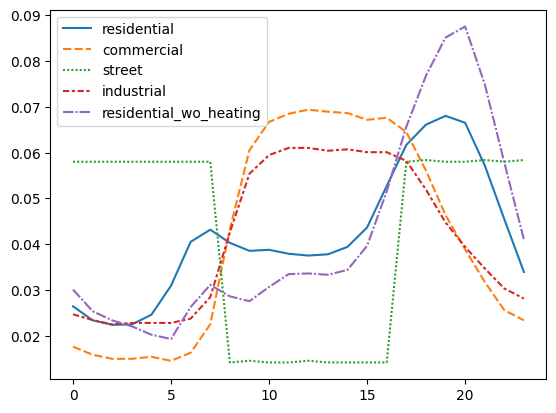

In [171]:

res_load = pd.read_csv('../data/us_24h_load_data_res.csv')
nonev_norm_without_heating = pd.read_excel('../data/nonEV_norm_without_heating.xlsx')

nonev_norm_without_heating['residential'] = res_load['w_heating']/res_load['w_heating'].sum()
nonev_norm_without_heating['residential_wo_heating'] = res_load['wo_heating']/res_load['wo_heating'].sum()

sns.lineplot(nonev_norm_without_heating.drop(columns=['time']))


In [2]:
nonev_norm_without_heating.to_excel('../../data/nonEV_norm_without_heating.xlsx')

NameError: name 'nonev_norm_without_heating' is not defined

<Axes: >

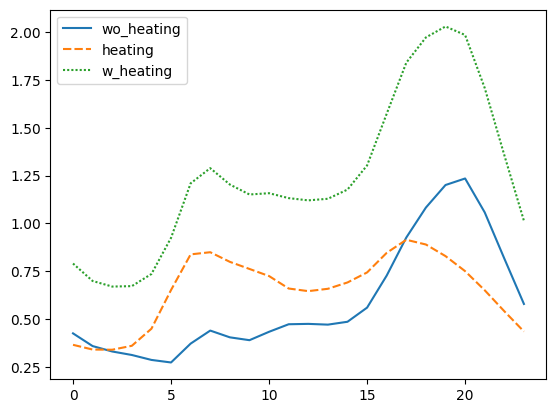

In [17]:
import pandas as pd 
data = pd.read_csv('../data/us_24h_load_data_res.csv')
import seaborn as sns

sns.lineplot(data.drop(columns=['Unnamed: 0']))

# Generating Latex tables

In [1]:
import pandas as pd
import numpy as np

def df_to_latex_table(df, data_column, caption=None, label=None):
    """
    Convert a DataFrame with Province, Year, and a data column into a LaTeX table
    where provinces are rows and years are columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing 'Province', 'Year', and a data column
    data_column : str
        Name of the column containing the data to be displayed
    caption : str, optional
        Caption for the LaTeX table
    label : str, optional
        Label for referencing the table in LaTeX
    
    Returns:
    --------
    str : LaTeX table code
    """
    # Verify required columns exist
    required_cols = ['Province', 'Year']
    if not all(col in df.columns for col in required_cols + [data_column]):
        missing = [col for col in required_cols + [data_column] if col not in df.columns]
        raise ValueError(f"Missing required columns: {missing}")
    
    # Pivot the DataFrame
    pivot_table = df.pivot(
        index='Province',
        columns='Year',
        values=data_column
    )
    
    # Sort years if they're not already sorted
    pivot_table = pivot_table.reindex(sorted(pivot_table.columns), axis=1)
    
    # Start building LaTeX code
    latex_code = []
    latex_code.append("\\begin{table}[htbp]")
    latex_code.append("\\centering")
    
    if caption:
        latex_code.append(f"\\caption{{{caption}}}")
    if label:
        latex_code.append(f"\\label{{{label}}}")
    
    # Create the tabular environment header
    n_years = len(pivot_table.columns)
    latex_code.append(f"\\begin{{tabular}}{{l{'c' * n_years}}}")
    
    # Add column headers (Years)
    header = "\textbf{Province} & " + " & ".join(f'\textbf{{{str(year)}}}' for year in pivot_table.columns) + " \\"
    latex_code.append("\hline")
    latex_code.append(header)
    latex_code.append("\hline")
    
    # Add data rows
    for province in pivot_table.index:
        row_data = pivot_table.loc[province]
        row = f"{province} & " + " & ".join(
            f"{x:.2f}" if pd.notnull(x) else "---" 
            for x in row_data
        ) + " \\"
        latex_code.append(row)
    
    # Close the table
    latex_code.append("\hline")
    latex_code.append("\end{tabular}")
    latex_code.append("\end{table}")
    
    return "".join(latex_code)


In [67]:
load_forecast_data = pd.read_csv('../../results/heatpump_forecast/electric_energy_n_load_profile_forecast_hp_fixed_penrate.csv')


In [22]:
#HP provincewise Energy
provinces = load_forecast_data['province'].unique()

load_forecast_data['total_electric_energy_GWh'] = load_forecast_data['total_electric_energy_MWh']/1000
energy_df = load_forecast_data[load_forecast_data['forecast_year'].isin(np.arange(2025,2055, 5))][['forecast_year','province','total_electric_energy_GWh']]


energy_df.rename(columns={'province':'Province', 'forecast_year': 'Year'},inplace=True )
df_to_latex_table(energy_data, 'power_required (GWh)')

NameError: name 'load_forecast_data' is not defined

In [123]:
# HP provincewise peak load


col_names = ['load_profile_24h_max_MWh']
for col_name in col_names:
    provinces = load_forecast_data['province'].unique()
    provincewise_load_profile_total = pd.DataFrame()
    for province in provinces:
        for year in np.arange(2025, 2055, 5):
            provincewise_load_profile = pd.DataFrame()
            load_data_province = load_forecast_data[(load_forecast_data['province']==province) & (load_forecast_data['forecast_year']==year)]
            load_data_mean_profile = np.array(load_data_province[col_name])
            array_data = []
            for data in load_data_mean_profile:
                data = data.strip('[]')
                data = re.sub(r'\n', '', data)
                data = data.split(' ')
                #print(len(data))
                array_data.append([val for val in data if len(val)>0])
            array_data = np.array(array_data).astype(float)
            provincewise_load_profile['Province'] = [province]
            provincewise_load_profile['load_data'] = array_data.max()
            provincewise_load_profile['Year'] = [year]
            provincewise_load_profile_total = pd.concat([provincewise_load_profile_total, provincewise_load_profile])
            
    # ax = sns.lineplot(provincewise_load_profile)
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    # ax.set(xlabel ="Hour of the Day", ylabel = "Load MW")
    # ax.set_xlim(0,23)
    # plt.grid(True, linestyle='--')
    # plt.savefig(f'{save_folder}/hp_provincewise_{col_name}_{year}.svg', format='svg', bbox_inches='tight')
    # plt.close()

In [126]:
# MHDEV provincewise Energy
provincewise_load_profile_total[provincewise_load_profile_total['Year']==2050]

,Province,load_data,Year
0,Alberta,1362.875738,2050
0,British Columbia,1073.451058,2050
0,Manitoba,491.044866,2050
0,New Brunswick,191.073619,2050
0,Newfoundland and Labrador,88.540774,2050
0,Nova Scotia,293.866407,2050
0,Ontario,8099.777098,2050
0,Prince Edward Island,29.708538,2050
0,Quebec,5278.045136,2050
0,Saskatchewan,320.498489,2050


In [96]:
# MHDEV provincewise peak load

In [132]:
provincewise_load_profile_total.groupby(['Year']).sum()

,Province,load_data
Year,,
2025,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2128.645168
2030,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,3929.955948
2035,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,6738.569949
2040,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,10336.284456
2045,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,14063.618224
2050,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,17251.739989


NameError: name 'save_folder' is not defined

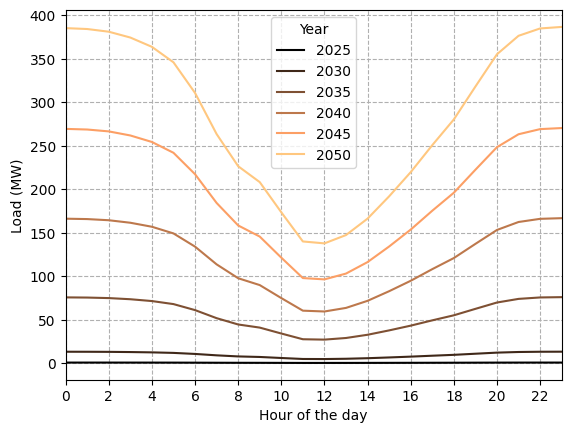

In [136]:
load_data = pd.read_csv('../../results/load_forecast/daily_load_profile_across_year_province_charge_type_high_adopt.csv')

#load_data.drop(columns=['Unnamed: 0'])
load_data.rename(columns={'hour':'Hour of the day', 'year': 'Year', 'province': 'Province'} ,inplace=True)

load_type = ['depot', 'opportunity']
load_data['Load (MW)'] = load_data['load (kw)']/1000

vehicle_type = ['mdev','hdev']
load_data_years = load_data[load_data['Year'].isin(range(2025,2055,5))]
for load in load_type:
    for vehicle in vehicle_type:

        load_spec = load_data_years[(load_data_years['load_type']==load) & (load_data_years['vehicle_type']==vehicle)]

        ax = sns.lineplot(load_spec, x='Hour of the day', y='Load (MW)', hue='Year', errorbar=None, palette='copper')
        ax.set_xlim(0, 23)
        ax.set_xticks(ticks=np.arange(0,24,2), labels=np.arange(0,24,2))

        fig = ax.get_figure()
        plt.grid(True, linestyle='--')
        
        plt.savefig(f"{save_folder}/{vehicle}_{load}_24hpattern.svg", format='svg', bbox_inches='tight')
        plt.close()

load_data_2050 = load_data_years[load_data_years['Year']==2050]


In [150]:
load_data_clean =load_data.groupby(['Province', 'Year', 'Hour of the day'], as_index=False).sum()[['Province', 'Year', 'Hour of the day', 'Load (MW)']]

load_data_clean = load_data_clean.groupby(['Province', 'Year'], as_index=False).max()[['Province', 'Year', 'Hour of the day', 'Load (MW)']]
load_data_clean = load_data_clean[load_data_clean['Year'].isin(np.arange(2025, 2055, 5))]

In [20]:
fnames = ["../../results/energy_forecast/canadawide_energy_requirement_forecast_mdev_high_adopt.csv", 
          "../../results/energy_forecast/canadawide_energy_requirement_forecast_hdev_high_adopt.csv"]
full_df = pd.concat([pd.read_csv(fnames[0]), pd.read_csv(fnames[1])])
#full_df = full_df[(full_df['fuel_type']=='Battery electric')]
# & (full_df['vehicle_type']=='Total, vehicles weighing 4,536 to 11,793 kilograms')
energy_data = full_df[full_df['year'].isin(np.arange(2025,2055,5))].groupby(['year', 'fuel_type'], as_index=False).sum()[['province', 'year', 'market_share_numbers', 'fuel_type', 'power_required (GWh)']]


energy_data.rename(columns={'province': 'Province', 'year': 'Year'}, inplace=True)

,Province,Year,market_share_numbers,fuel_type,power_required (GWh)
0,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2025,1.312620e+06,All fuel type,0.000000
1,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2025,1.008902e+03,Battery electric,38.020944
2,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2030,1.470607e+06,All fuel type,0.000000
3,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2030,2.663758e+04,Battery electric,1287.365249
4,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2035,1.646602e+06,All fuel type,0.000000
5,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2035,1.619499e+05,Battery electric,8165.455877
6,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2040,1.843663e+06,All fuel type,0.000000
7,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2040,3.558969e+05,Battery electric,17946.872369
8,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2045,2.064309e+06,All fuel type,0.000000
9,AlbertaBritish ColumbiaManitobaNew BrunswickNe...,2045,5.762074e+05,Battery electric,29017.779681


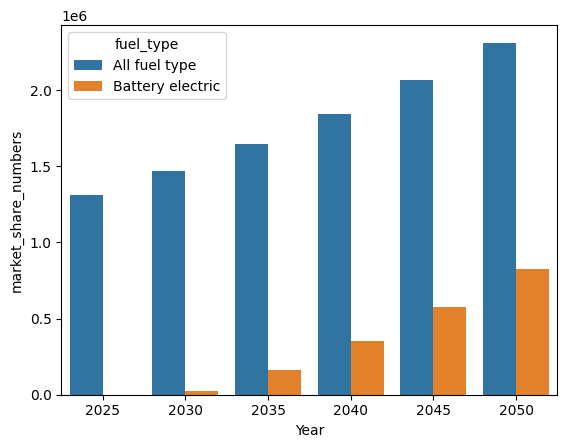

In [22]:
import seaborn as sns 

sns.barplot(energy_data, x='Year', y='market_share_numbers', hue='fuel_type')
energy_data

In [52]:
ms = np.array(energy_data.groupby('Year').sum()['market_share_numbers'])
(ms[1:] - ms[0:-1]).mean()


21646.601327215292

In [28]:
df_to_latex_table(energy_data, 'market_share_numbers')

'\\begin{table}[htbp]\\centering\\begin{tabular}{lcccccc}\\hline\textbf{Province} & \textbf{2025} & \textbf{2030} & \textbf{2035} & \textbf{2040} & \textbf{2045} & \textbf{2050} \\\\hlineAlberta & 63.72 & 2515.19 & 16291.55 & 35808.09 & 57859.46 & 82556.25 \\British Columbia & 33.94 & 1339.61 & 8677.01 & 19071.67 & 30816.41 & 43970.12 \\Manitoba & 22.24 & 877.98 & 5686.93 & 12499.62 & 20197.16 & 28818.13 \\New Brunswick & 7.02 & 277.19 & 1795.44 & 3946.31 & 6376.52 & 9098.29 \\Newfoundland and Labrador & 3.02 & 119.12 & 771.59 & 1695.91 & 2740.29 & 3909.96 \\Northwest Territories & 0.54 & 21.16 & 137.08 & 301.31 & 486.86 & 694.67 \\Nova Scotia & 6.91 & 272.69 & 1766.29 & 3882.23 & 6272.99 & 8950.55 \\Nunavut & 0.26 & 10.08 & 65.30 & 143.53 & 231.92 & 330.92 \\Ontario & 82.67 & 3263.33 & 21137.45 & 46459.15 & 75069.68 & 107112.50 \\Prince Edward Island & 2.56 & 100.86 & 653.29 & 1435.90 & 2320.16 & 3310.50 \\Quebec & 40.60 & 1602.74 & 10381.37 & 22817.77 & 36869.44 & 52606.83 \\Saskatch

In [37]:
import pandas as pd 
import numpy as np
data = pd.read_csv('../../data/formatted_data/heatpump/hp_penetration_rate_forecast_by_group_all_province.csv')
data = data[data['Year']==2050]

In [5]:
data['hp_numbers'] = data['number_of_houses'] * data['Penetration Rate (%)']/100

In [14]:
data_summed = data.groupby(['province', 'Year'], as_index=False).sum()

In [29]:
data_summed['HP_penrate'] = data_summed['hp_numbers']/data_summed['number_of_houses']*100

In [35]:
data_summed_clean = data_summed.loc[:, ['province','Year','HP_penrate']]
data_summed_clean.rename(columns={'province':'Province'}, inplace=True)
data_summed_clean  = data_summed_clean[data_summed_clean['Year'].isin(np.arange(2025, 2055, 5))]

In [8]:
df_to_latex_table(energy_data, 'market_share_numbers')

'\\begin{table}[htbp]\\centering\\begin{tabular}{lcccccc}\\hline\textbf{Province} & \textbf{2025} & \textbf{2030} & \textbf{2035} & \textbf{2040} & \textbf{2045} & \textbf{2050} \\\\hlineAlberta & 332276.87 & 378547.97 & 457654.84 & 556840.40 & 668467.39 & 793473.88 \\British Columbia & 237876.22 & 271083.71 & 327454.28 & 398388.62 & 478288.11 & 567768.97 \\Manitoba & 65535.54 & 74654.74 & 90278.92 & 109846.65 & 131863.97 & 156519.98 \\New Brunswick & 25817.93 & 29413.20 & 35559.56 & 43266.00 & 51939.29 & 61652.17 \\Newfoundland and Labrador & 13136.90 & 14981.26 & 18062.00 & 21966.81 & 26377.22 & 31317.81 \\Northwest Territories & 3198.11 & 3642.57 & 4406.76 & 5362.08 & 6436.59 & 7639.85 \\Nova Scotia & 28963.60 & 32988.83 & 39909.71 & 48561.61 & 58292.90 & 69190.20 \\Nunavut & 784.13 & 893.10 & 1080.47 & 1314.70 & 1578.15 & 1873.17 \\Ontario & 324521.47 & 369616.46 & 447164.88 & 544100.62 & 653127.90 & 775218.94 \\Prince Edward Island & 7857.97 & 8950.03 & 10827.70 & 13175.01 & 15815

In [30]:
data_summed

,province,Year,Unnamed: 0,house_type,year_of_construction,number_of_houses,Penetration Rate (%),electric,non_electric,hp_numbers,HP_penrate
0,Alberta,2024,0,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,1737428,87.036833,212906.0,1483549.0,54980.743722,3.164490
1,Alberta,2025,33,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,1737428,99.753999,212906.0,1483549.0,63014.115137,3.626862
2,Alberta,2026,66,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,1737428,114.026104,212906.0,1483549.0,72029.734860,4.145768
3,Alberta,2027,99,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,1737428,129.953395,212906.0,1483549.0,82090.926798,4.724853
4,Alberta,2028,132,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,1737428,147.616593,212906.0,1483549.0,93248.682691,5.367053
...,...,...,...,...,...,...,...,...,...,...,...
292,Territories,2046,726,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,43934,757.307635,1103.0,42831.0,10082.288985,22.948716
293,Territories,2047,759,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,43934,776.573560,1103.0,42831.0,10338.782660,23.532532
294,Territories,2048,792,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,43934,793.142378,1103.0,42831.0,10559.368864,24.034618
295,Territories,2049,825,Single_DetachSingle_DetachSingle_DetachSingle_...,0_19451946_19601961_19771978_19831984_19951996...,43934,807.285954,1103.0,42831.0,10747.666996,24.463211
